# Wikipedia Editing Event Study: US Federal Elections 2008-2024

**Version: 12/28/2024 - HTML-Parsed Data Pipeline**

This notebook analyzes Wikipedia editing patterns for US House and Senate *candidates* using data collected by parsing Wikipedia election result pages and continues using the window design 

* Cycle-specific metadata: specific party/office for each election
* only includes edits during the 2-year cycles (preceding election) when this particular candidate was on ballot.

## Data Pipeline (Updated)

**Step 1**: Parse Wikipedia Election Pages
- `011_build_house_roster_backend.py` extracts House candidates from Wikipedia election pages
- `012_build_senate_roster.py` extracts Senate candidates from Wikipedia election pages
- **Output**: 18 CSV files (2008-2024, House+Senate) in `data/raw/html_parsed_candidates/`

**Step 2**: `021_collect_revisions.py` collects edit histories via Wikipedia API
- **Output**: 2,341 revision JSON files in `data/raw/revisions_html_parsed/`

**Step 3**: `031_process_data.py` enriches revisions with cycle-specific metadata, filter to on-ballot candidates
- **Output**: analysis-ready datasets in `data/processed_html_parsed/`


## Analysis overview
1. Non-overlapping 2-year cycles prevents contamination between elections. excludes immediate post-election editing spikes.
2. Event study design compares baseline and pre-election editing
3. Segment candidates along differennt axes of differentiation, including by office, state, party, competitiveness of their district (PVI)

## Progress check
[Updated]:
1. Collect pages of candidates who appeared on the November ballot AND have Wikipedia pages, probably through directly parsing Wikipedia pages on elections. (https://en.wikipedia.org/wiki/2022_United_States_House_of_Representatives_elections#Arizona)
2. Updated Section 1-3

[TODO]:
1. Update Section 4 onwards
2. DiD with off-ballot candidates.
3. Separately consider general informational pages, which may demonstrate different editing patterns (perhaps less contested, less astroturfing, etc. )


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, date, timedelta
from pathlib import Path
import warnings
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Environment configured")


Environment configured


In [15]:
import sys
from pathlib import Path

# Add scripts directory to path
scripts_dir = Path('../scripts')
if str(scripts_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(scripts_dir.resolve()))

# Import election cycle utilities
from election_cycles import (
    get_election_day, get_cycle_windows, get_study_cycles,
    date_to_event_time, get_on_ballot_indicator,
    is_presidential_year, ELECTION_METADATA
)

# Display election days and cycles for full study period (2008-2024)
print("Election Days (2008-2024):")
for year in [2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]:
    ed = get_election_day(year)
    election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    print(f"  {year} ({election_type:12s}): {ed.strftime('%A, %B %d, %Y')}")

print("\nStudy Cycles (2008-2024):")
cycles = get_study_cycles(2008, 2024)
for c in cycles:
    print(f"  {c['election_year']}: {c['cycle_start']} to {c['cycle_end']} ({c['type']})")


Election Days (2008-2024):
  2008 (presidential): Tuesday, November 04, 2008
  2010 (midterm     ): Tuesday, November 02, 2010
  2012 (presidential): Tuesday, November 06, 2012
  2014 (midterm     ): Tuesday, November 04, 2014
  2016 (presidential): Tuesday, November 08, 2016
  2018 (midterm     ): Tuesday, November 06, 2018
  2020 (presidential): Tuesday, November 03, 2020
  2022 (midterm     ): Tuesday, November 08, 2022
  2024 (presidential): Tuesday, November 05, 2024

Study Cycles (2008-2024):
  2008: 2006-11-08 to 2008-11-04 (presidential)
  2010: 2008-11-05 to 2010-11-02 (midterm)
  2012: 2010-11-03 to 2012-11-06 (presidential)
  2014: 2012-11-07 to 2014-11-04 (midterm)
  2016: 2014-11-05 to 2016-11-08 (presidential)
  2018: 2016-11-09 to 2018-11-06 (midterm)
  2020: 2018-11-07 to 2020-11-03 (presidential)
  2022: 2020-11-04 to 2022-11-08 (midterm)
  2024: 2022-11-09 to 2024-11-05 (presidential)


## 1. Load Data and Overview Statistics

In [34]:
# Set data directory
data_dir = Path('../data/processed_html_parsed')

if not data_dir.exists():
    raise FileNotFoundError(
        f"Processed data not found at {data_dir}\n"
        "Please run: python scripts/031_process_data.py"
    )

# Load processed datasets
print("Loading datasets...")
df_daily = pd.read_csv(data_dir / 'daily_edits.csv', parse_dates=['date'])
df_candidates = pd.read_csv(data_dir / 'candidate_cycle_stats.csv')
df_revisions = pd.read_csv(data_dir / 'all_revisions.csv', parse_dates=['timestamp'])

print(f"✓ Loaded {len(df_revisions):,} revisions")
print(f"✓ Loaded {len(df_daily):,} daily records")
print(f"✓ Loaded {len(df_candidates):,} candidate-cycle records")

# Load and display processing summary
summary_path = data_dir / 'processing_summary.md'
if summary_path.exists():
    print(f"\n{'='*80}")
    print("PROCESSING SUMMARY")
    print('='*80)

    with open(summary_path, 'r', encoding='utf-8') as f:
        summary_md = f.read()

    display(Markdown(summary_md))
else:
    print("Warning: processing_summary.md not found")

# Quick overview
print(f"\n{'='*80}")
print("QUICK DATASET OVERVIEW")
print('='*80)
print(f"Unique candidates: {df_revisions['page_title'].nunique():,}")
print(f"Unique editors: {df_revisions['user'].nunique():,}")
print(f"Date range: {df_revisions['timestamp'].min().date()} to {df_revisions['timestamp'].max().date()}")
print(f"Election cycles: {sorted(df_candidates['election_cycle'].unique())}")

print(f"\n{'='*80}")
print(f"\nWikipedia Candidate Coverage Summary (2008-2024):")
print('='*80)
print(f"  House:  {df_coverage_house['with_wiki'].sum():,} out of {df_coverage_house['total'].sum():,} "
      f"candidates ({100*df_coverage_house['with_wiki'].sum()/df_coverage_house['total'].sum():.1f}%)")
print(f"  Senate: {df_coverage_senate['with_wiki'].sum():,} out of {df_coverage_senate['total'].sum():,} "
      f"candidates ({100*df_coverage_senate['with_wiki'].sum()/df_coverage_senate['total'].sum():.1f}%)")
print(f"  TOTAL:  {df_coverage_house['with_wiki'].sum() + df_coverage_senate['with_wiki'].sum():,} out of "
      f"{df_coverage_house['total'].sum() + df_coverage_senate['total'].sum():,} "
      f"candidates ({100*(df_coverage_house['with_wiki'].sum() + df_coverage_senate['with_wiki'].sum())/(df_coverage_house['total'].sum() + df_coverage_senate['total'].sum()):.1f}%)")


Loading datasets...
✓ Loaded 600,882 revisions
✓ Loaded 273,410 daily records
✓ Loaded 5,098 candidate-cycle records

PROCESSING SUMMARY


# Data Processing Summary

**Processing Date**: 2025-12-29 05:11:01

*Note: This summary was generated from existing processed files.*

---

## NOTE: Sample Composition

Candidates with Wikipedia pages represents approximately **50.2%** of all on-ballot candidates (2008-2024).

| Office | With Wikipedia | Total On-Ballot | Coverage |
|--------|---------------:|----------------:|---------:|
| House | 5,097 | 10,310 | 49.4% |
| Senate | 636 | 1,120 | 56.8% |
| **Total** | **5,733** | **11,430** | **50.2%** |

**Selection bias to consider later on in terms of drawing conclusion regarding attention mechanism:** sample over-represents:
- More prominent/well-known/better-funded candidates
- Major party candidates (Democratic/Republican)
- Incumbents and serious challengers

---

## Dataset Overview
- **Total Revisions**: 600,882
- **Unique Candidates**: 2,022
- **Unique Editors**: 105,449
- **Date Range**: 2006-11-08 to 2024-11-05
- **Election Cycles Covered**: 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024

---

## Edit Types

| Type | Count | Percentage |
|------|------:|:----------:|
| Anonymous edits | 135,554 | 22.6% |
| Bot edits | 22,081 | 3.7% |
| Minor edits | 123,208 | 20.5% |

---

## Distribution by Office

| Office | Revisions | Percentage | Candidates |
|--------|----------:|:----------:|:----------:|
| House | 461,950 | 76.9% | 1688 |
| Senate | 138,932 | 23.1% | 415 |

---

## Distribution by Election Cycle

| Cycle | Revisions | Percentage | Candidates | House | Senate |
|------:|----------:|:----------:|:----------:|------:|-------:|
| 2008 | 93,215 | 15.5% | 599 | 531 | 68 |
| 2010 | 85,567 | 14.2% | 627 | 556 | 71 |
| 2012 | 59,812 | 10.0% | 623 | 555 | 68 |
| 2014 | 46,991 | 7.8% | 585 | 509 | 76 |
| 2016 | 33,975 | 5.7% | 455 | 388 | 67 |
| 2018 | 70,474 | 11.7% | 583 | 517 | 66 |
| 2020 | 73,582 | 12.2% | 550 | 489 | 61 |
| 2022 | 74,273 | 12.4% | 553 | 488 | 65 |
| 2024 | 62,993 | 10.5% | 523 | 464 | 59 |

---

## Distribution by Party

| Party | Revisions | Percentage | Candidates |
|-------|----------:|:----------:|:----------:|
| Republican | 310,072 | 51.6% | 917 |
| Democratic | 265,409 | 44.2% | 967 |
| DFL | 11,589 | 1.9% | 25 |
| Independent | 8,129 | 1.4% | 44 |
| Libertarian | 1,146 | 0.2% | 22 |

---

## Top 15 States by Revision Count

| Rank | State | Revisions | Percentage | Candidates |
|-----:|-------|----------:|:----------:|:----------:|
| 1 | California | 61,818 | 10.3% | 173 |
| 2 | New York | 41,683 | 6.9% | 115 |
| 3 | Texas | 37,864 | 6.3% | 98 |
| 4 | Florida | 35,582 | 5.9% | 100 |
| 5 | Illinois | 23,873 | 4.0% | 67 |
| 6 | Ohio | 22,150 | 3.7% | 67 |
| 7 | Minnesota | 21,177 | 3.5% | 50 |
| 8 | Pennsylvania | 19,937 | 3.3% | 89 |
| 9 | Georgia | 18,387 | 3.1% | 53 |
| 10 | Virginia | 17,275 | 2.9% | 61 |
| 11 | Massachusetts | 17,254 | 2.9% | 31 |
| 12 | Michigan | 16,177 | 2.7% | 69 |
| 13 | Arizona | 14,847 | 2.5% | 51 |
| 14 | North Carolina | 14,597 | 2.4% | 67 |
| 15 | New Jersey | 13,692 | 2.3% | 56 |

---

## Top 15 Most Edited Candidates

| Rank | Candidate | Total Revisions | Unique Editors |
|-----:|-----------|----------------:|---------------:|
| 1 | Nancy Pelosi | 8,241 | 3,471 |
| 2 | Ron Paul | 7,478 | 2,152 |
| 3 | Alexandria Ocasio-Cortez | 4,751 | 1,474 |
| 4 | Michele Bachmann | 4,205 | 1,489 |
| 5 | Paul Ryan | 3,700 | 1,044 |
| 6 | Ilhan Omar | 3,409 | 1,026 |
| 7 | Marjorie Taylor Greene | 2,729 | 667 |
| 8 | Lauren Boebert | 2,710 | 812 |
| 9 | Marco Rubio | 2,582 | 859 |
| 10 | Joe Biden | 2,511 | 983 |
| 11 | Debbie Wasserman Schultz | 2,451 | 1,300 |
| 12 | Jim Jordan | 2,423 | 1,241 |
| 13 | Barney Frank | 2,300 | 961 |
| 14 | Elizabeth Warren | 2,274 | 718 |
| 15 | Mike Johnson | 2,263 | 610 |

---

## Generated Files

| File | Rows | Description |
|------|-----:|:------------|
| `all_revisions.csv` | 600,882 | All revisions with metadata |
| `daily_edits.csv` | 273,410 | Daily aggregates |
| `daily_edits_house.csv` | 219,845 | Daily aggregates (House only) |
| `daily_edits_senate.csv` | 53,565 | Daily aggregates (Senate only) |
| `candidate_cycle_stats.csv` | 5,098 | Candidate-cycle statistics |
| `editor_profiles.csv` | 259,971 | Editor profiles |


QUICK DATASET OVERVIEW
Unique candidates: 2,022
Unique editors: 105,449
Date range: 2006-11-08 to 2024-11-05
Election cycles: [np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022), np.int64(2024)]

Wikipedia Candidate Coverage Summary (2008-2024):
  House:  5,097 out of 10,310 candidates (49.4%)
  Senate: 636 out of 1,120 candidates (56.8%)
  TOTAL:  5,733 out of 11,430 candidates (50.2%)


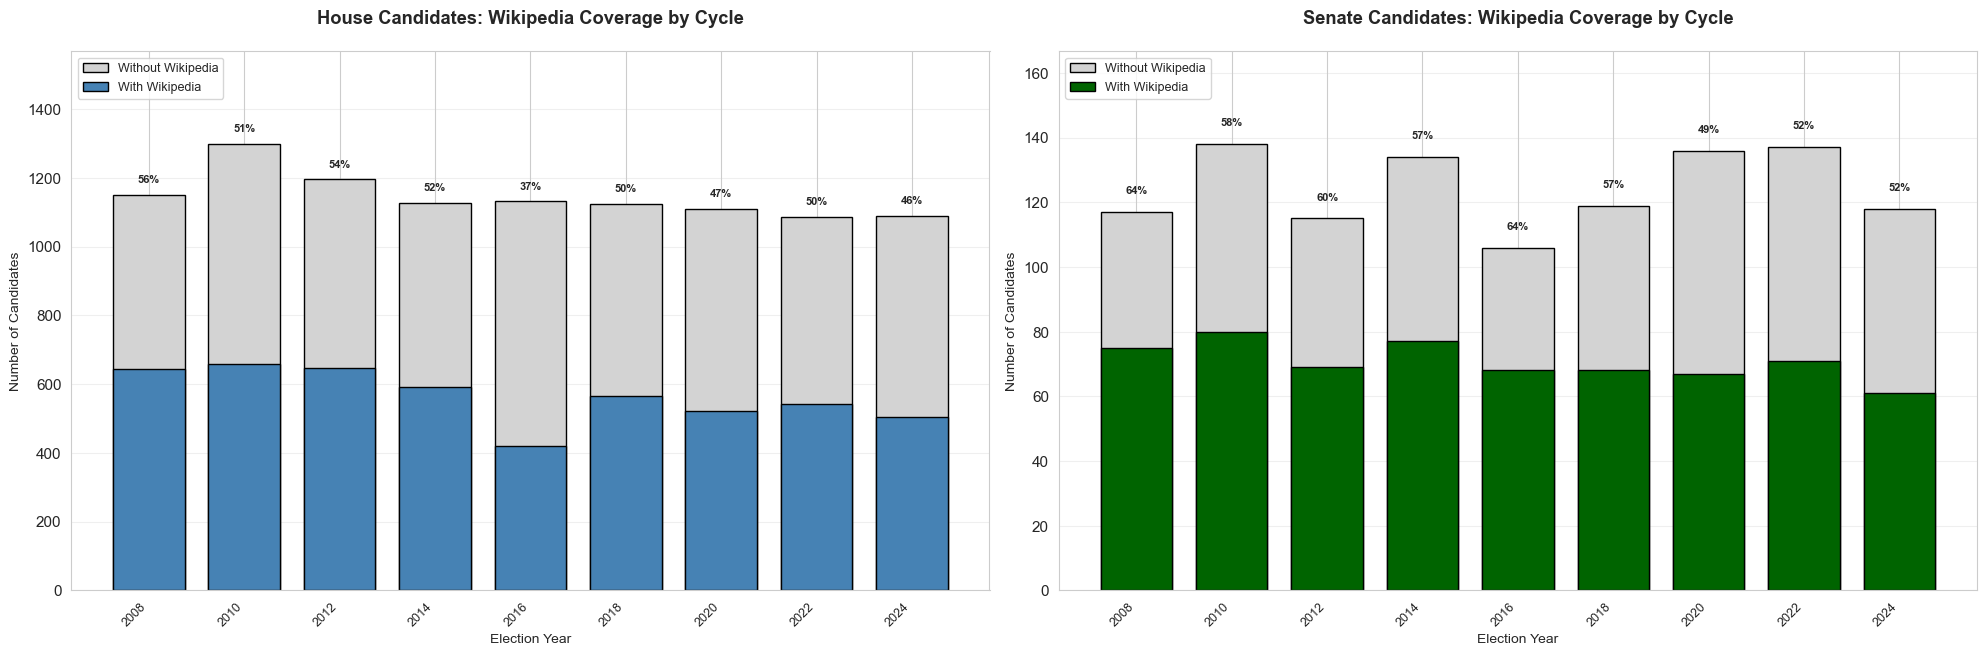

In [37]:
# ============================================================================
# Wikipedia Coverage Visualization
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Coverage over time - House
ax = axes[0]
years = df_coverage_house['year'].values
ax.bar(years, df_coverage_house['total'].values, color='lightgray',
       edgecolor='black', label='Without Wikipedia', width=1.5)
ax.bar(years, df_coverage_house['with_wiki'].values, color='steelblue',
       edgecolor='black', label='With Wikipedia', width=1.5)
ax.set_title('House Candidates: Wikipedia Coverage by Cycle', fontweight='bold', pad=20)
ax.set_xlabel('Election Year', fontsize=10)
ax.set_ylabel('Number of Candidates', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)

# Add coverage percentage on top with more space
for i, (y, total, wiki) in enumerate(zip(years, df_coverage_house['total'], df_coverage_house['with_wiki'])):
    pct = 100 * wiki / total
    ax.text(y, total + 30, f'{pct:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
# Add margin at top for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# 2. Coverage over time - Senate
ax = axes[1]
years = df_coverage_senate['year'].values
ax.bar(years, df_coverage_senate['total'].values, color='lightgray',
       edgecolor='black', label='Without Wikipedia', width=1.5)
ax.bar(years, df_coverage_senate['with_wiki'].values, color='darkgreen',
       edgecolor='black', label='With Wikipedia', width=1.5)
ax.set_title('Senate Candidates: Wikipedia Coverage by Cycle', fontweight='bold', pad=20)
ax.set_xlabel('Election Year', fontsize=10)
ax.set_ylabel('Number of Candidates', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)

# Add coverage percentage on top with more space
for i, (y, total, wiki) in enumerate(zip(years, df_coverage_senate['total'], df_coverage_senate['with_wiki'])):
    pct = 100 * wiki / total
    ax.text(y, total + 5, f'{pct:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
# Add margin at top for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.92)
plt.show()



### 1.2 Dataset Visualizations (House Candidates with Wiki Pages Only)

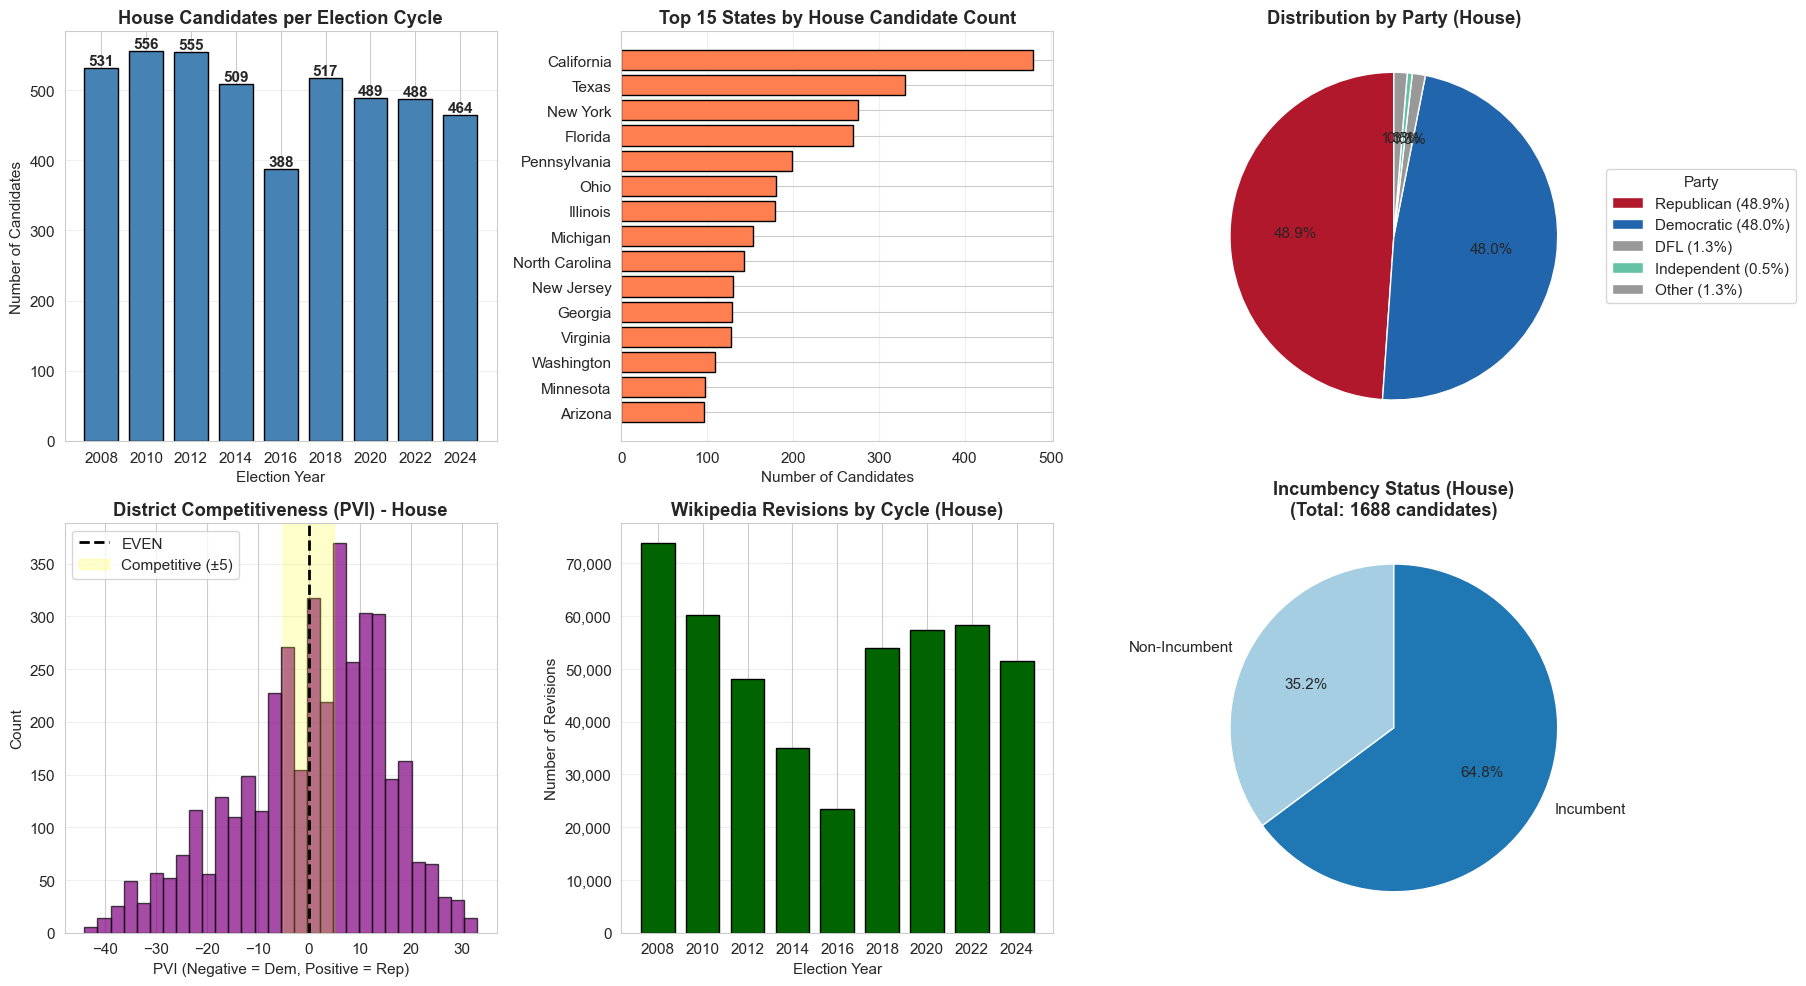

KEY INSIGHTS (Only House Candidates with Wiki Pages)
Coverage:
  - 1688 unique House candidates across 9 election cycles
  - 388 to 556 candidates per cycle

Party Balance:
  - Republican: 779 candidates (48.9% of candidate-cycles)
  - Democratic: 822 candidates (48.0% of candidate-cycles)
  - DFL: 22 candidates (1.3% of candidate-cycles)

Competitiveness:
  - 1074 candidate-cycles in competitive districts (PVI ≤ ±5)
  - 27.4% of races with PVI data

Editing Activity (House):
  - 83,179 unique editors
  - 17,651 bot edits (3.8%)
  - 105,305 anonymous edits (22.8%)

Temporal Pattern:
  - Average 51328 revisions per cycle
  - Peak cycle: 2008 with 73,961 revisions

Incumbency:
  - 2915 incumbent candidate-cycles (64.8%)
  - 1582 non-incumbent candidate-cycles (35.2%)


In [39]:
# Filter to House candidates only
df_candidates_house = df_candidates[df_candidates['office'] == 'House'].copy()
df_revisions_house = df_revisions[df_revisions['office'] == 'House'].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Candidates by Cycle (House)
ax = axes[0, 0]
cycle_counts = df_candidates_house.groupby('election_cycle')['page_title'].nunique().sort_index()
# Convert index to int to avoid decimal labels
years = [int(y) for y in cycle_counts.index]
ax.bar(years, cycle_counts.values, color='steelblue', edgecolor='black', width=1.5)
ax.set_title('House Candidates per Election Cycle', fontweight='bold')
ax.set_xlabel('Election Year')
ax.set_ylabel('Number of Candidates')
ax.set_xticks(years)
ax.set_xticklabels(years)
ax.grid(axis='y', alpha=0.3)
for year, v in zip(years, cycle_counts.values):
    ax.text(year, v, str(v), ha='center', va='bottom', fontweight='bold')

# 2. State Distribution (Top 15)
ax = axes[0, 1]
state_counts = df_candidates_house['state'].value_counts().head(15)
ax.barh(range(len(state_counts)), state_counts.values, color='coral', edgecolor='black')
ax.set_yticks(range(len(state_counts)))
ax.set_yticklabels(state_counts.index)
ax.set_title('Top 15 States by House Candidate Count', fontweight='bold')
ax.set_xlabel('Number of Candidates')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# 3. Party Distribution (Top 4 + Other with percentages)
ax = axes[0, 2]
party_counts = df_candidates_house['party'].value_counts()

# Get top 4 parties and combine rest as "Other"
top_4 = party_counts.head(4)
other_count = party_counts.iloc[4:].sum() if len(party_counts) > 4 else 0

# Create data for pie chart
if other_count > 0:
    plot_values = list(top_4.values) + [other_count]
    plot_labels = list(top_4.index) + ['Other']
else:
    plot_values = list(top_4.values)
    plot_labels = list(top_4.index)

# Calculate percentages for legend
total = sum(plot_values)
legend_labels = [f"{label} ({100*val/total:.1f}%)" for label, val in zip(plot_labels, plot_values)]

colors_party = {'Democratic': '#2166ac', 'Republican': '#b2182b', 'Libertarian': '#fdae61',
                'Independent': '#66c2a5', 'Green': '#5aae61', 'Other': '#999999'}
pie_colors = [colors_party.get(p, '#999999') for p in plot_labels]

# Create pie chart without labels on the chart itself
wedges, texts, autotexts = ax.pie(plot_values, autopct='%1.1f%%',
                                    colors=pie_colors, startangle=90)
ax.set_title('Distribution by Party (House)', fontweight='bold')

# Create legend outside the pie chart with percentages
ax.legend(wedges, legend_labels, title="Party", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 4. PVI Distribution (District Competitiveness)
ax = axes[1, 0]
pvi_data = df_candidates_house['pvi_numeric'].dropna()
ax.hist(pvi_data, bins=30, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='EVEN')
ax.axvspan(-5, 5, alpha=0.2, color='yellow', label='Competitive (±5)')
ax.set_title('District Competitiveness (PVI) - House', fontweight='bold')
ax.set_xlabel('PVI (Negative = Dem, Positive = Rep)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. Revision Volume by Cycle (House)
ax = axes[1, 1]
cycle_revisions = df_revisions_house.groupby('election_cycle')['revid'].count().sort_index()
years_rev = [int(y) for y in cycle_revisions.index]
ax.bar(years_rev, cycle_revisions.values, color='darkgreen', edgecolor='black', width=1.5)
ax.set_title('Wikipedia Revisions by Cycle (House)', fontweight='bold')
ax.set_xlabel('Election Year')
ax.set_ylabel('Number of Revisions')
ax.set_xticks(years_rev)
ax.set_xticklabels(years_rev)
ax.grid(axis='y', alpha=0.3)
# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 6. Incumbency Status (House)
ax = axes[1, 2]
incumbency_counts = df_candidates_house['candidate_was_incumbent'].value_counts()
incumbency_labels = ['Non-Incumbent', 'Incumbent']
incumbency_values = [incumbency_counts.get(False, 0), incumbency_counts.get(True, 0)]
colors_incumbency = ['#a6cee3', '#1f78b4']
ax.pie(incumbency_values, labels=incumbency_labels, autopct='%1.1f%%',
       colors=colors_incumbency, startangle=90)
ax.set_title(f'Incumbency Status (House)\n(Total: {df_candidates_house["page_title"].nunique()} candidates)',
             fontweight='bold')

plt.tight_layout()
plt.show()

# Key Insights (House only)
print(f"{'='*80}")
print("KEY INSIGHTS (Only House Candidates with Wiki Pages)")
print('='*80)
print(f"Coverage:")
print(f"  - {df_candidates_house['page_title'].nunique()} unique House candidates across {len(cycle_counts)} election cycles")
print(f"  - {cycle_counts.min():.0f} to {cycle_counts.max():.0f} candidates per cycle")

print(f"\nParty Balance:")
for party, count in party_counts.head(3).items():
    unique_candidates = df_candidates_house[df_candidates_house['party'] == party]['page_title'].nunique()
    print(f"  - {party}: {unique_candidates} candidates ({100*count/len(df_candidates_house):.1f}% of candidate-cycles)")

print(f"\nCompetitiveness:")
competitive = df_candidates_house[(df_candidates_house['pvi_numeric'].notna()) &
                                   (df_candidates_house['pvi_numeric'].abs() <= 5)]
print(f"  - {len(competitive)} candidate-cycles in competitive districts (PVI ≤ ±5)")
print(f"  - {100*len(competitive)/len(df_candidates_house[df_candidates_house['pvi_numeric'].notna()]):.1f}% of races with PVI data")

print(f"\nEditing Activity (House):")
print(f"  - {df_revisions_house['user'].nunique():,} unique editors")
print(f"  - {df_revisions_house['is_bot'].sum():,} bot edits ({100*df_revisions_house['is_bot'].mean():.1f}%)")
print(f"  - {df_revisions_house['is_anonymous'].sum():,} anonymous edits ({100*df_revisions_house['is_anonymous'].mean():.1f}%)")

print(f"\nTemporal Pattern:")
print(f"  - Average {df_revisions_house.groupby('election_cycle')['revid'].count().mean():.0f} revisions per cycle")
print(f"  - Peak cycle: {cycle_revisions.idxmax()} with {cycle_revisions.max():,} revisions")

print(f"\nIncumbency:")
incumbent_count = len(df_candidates_house[df_candidates_house['candidate_was_incumbent'] == True])
total_count = len(df_candidates_house)
print(f"  - {incumbent_count} incumbent candidate-cycles ({100*incumbent_count/total_count:.1f}%)")
print(f"  - {total_count - incumbent_count} non-incumbent candidate-cycles ({100*(total_count-incumbent_count)/total_count:.1f}%)")




## 2. Time Series: Daily Editing Activity

**Moving Averages**: All MAs use *backward-looking windows*. The 7-day moving average at day *t* represents the average of days (*t*-6, *t*-5, ..., *t*-1, *t*). This ensures pre-election averages are not contaminated by post-election editing activity.

Dataset Variations Summary:
          Variation  Total Revisions  Unique Pages  Days of Data  Avg Edits/Page/Day
           V1: Full           244607          1000          3653            2.089576
     V2: No Special           238863           976          3653            2.071408
V3: No Special/Pres           236136           970          3653            2.069683

Key Differences:
  V1 → V2: Removed special election cycles (idiosyncratic attention patterns)
  V2 → V3: Removed presidential candidates (different editing timespan)


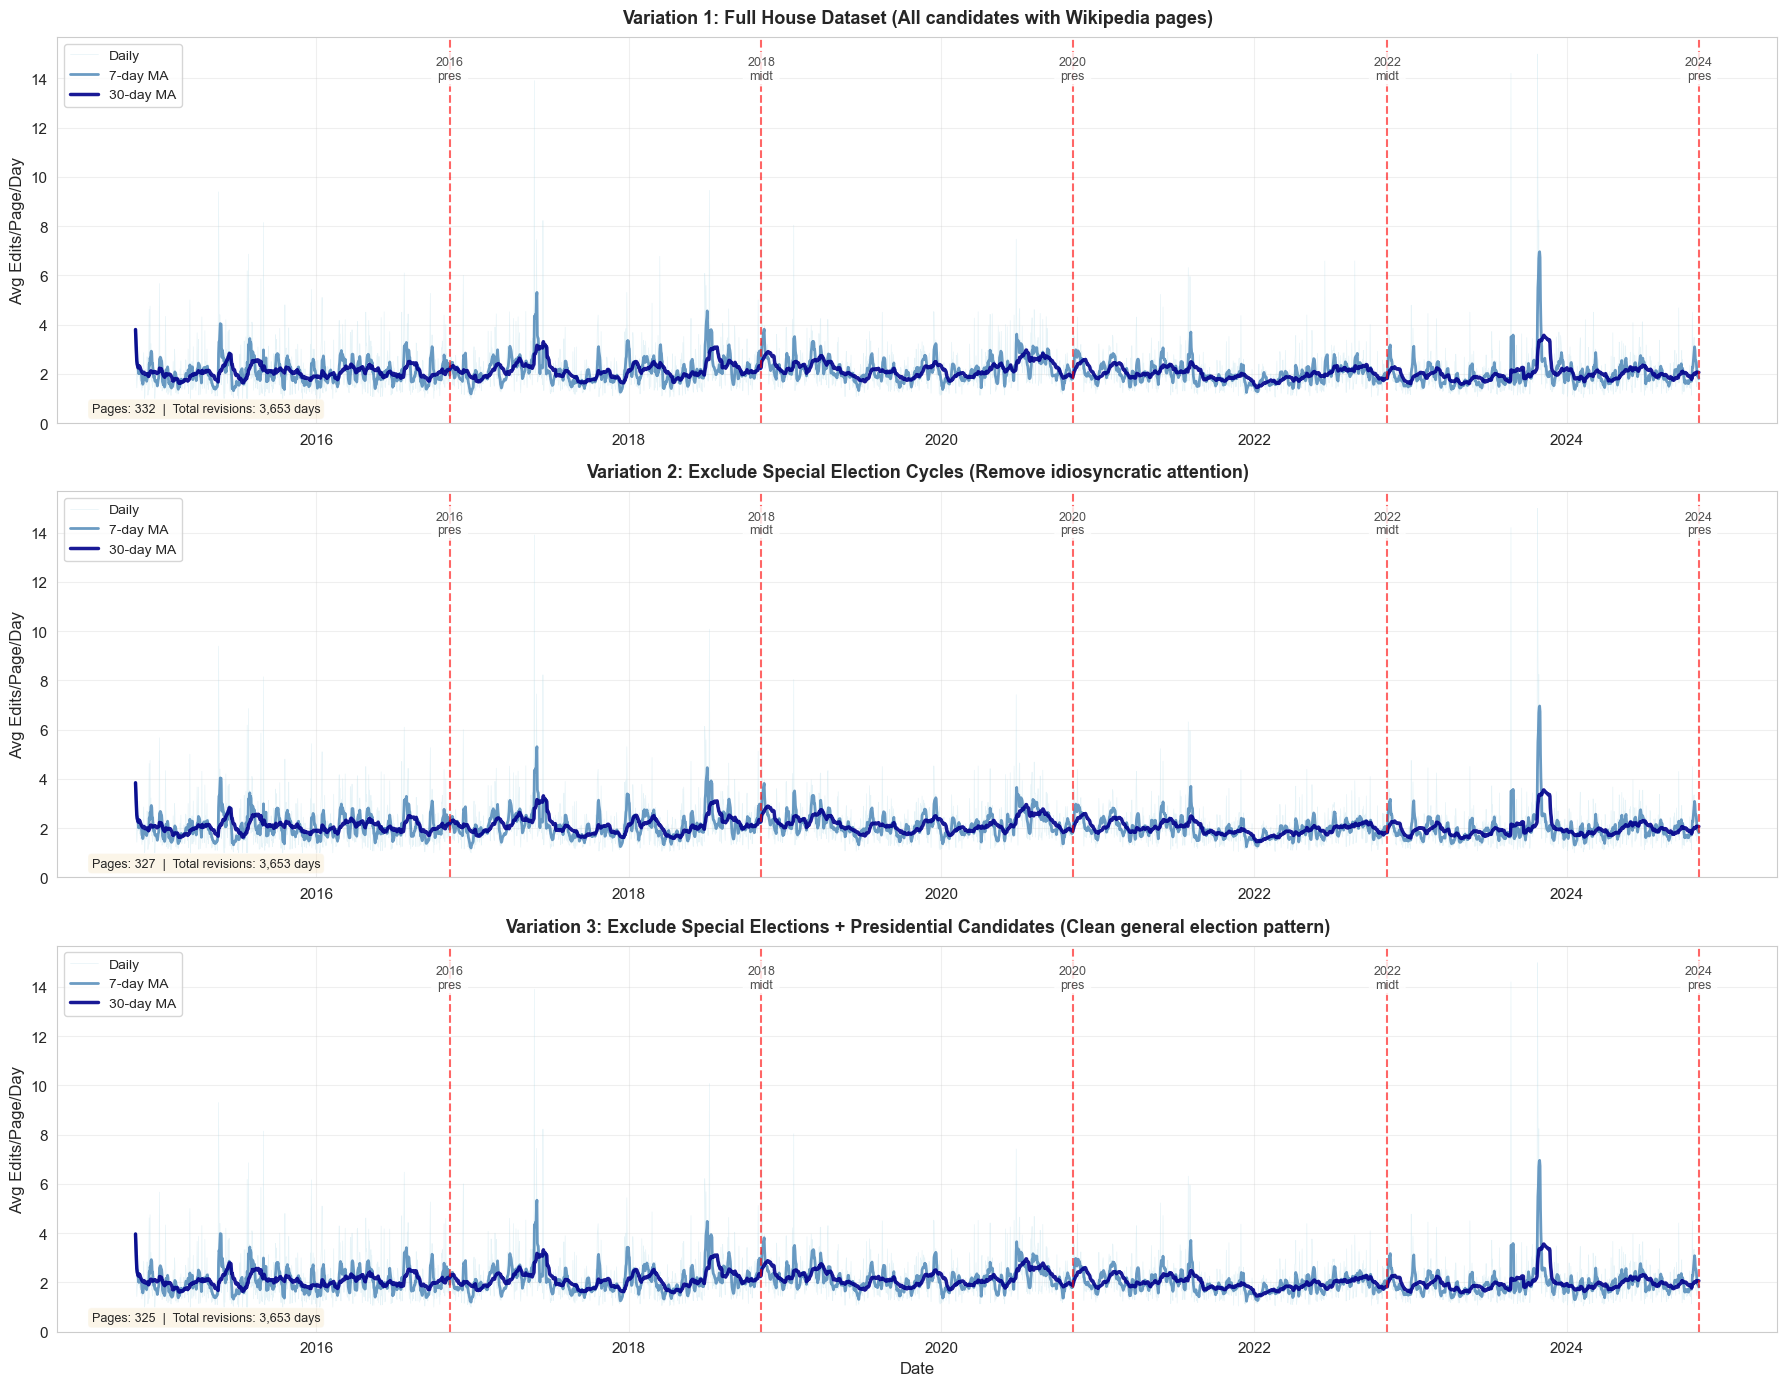


INTERPRETATION NOTES

1. TIME RANGE: 2014-11-05 onwards (2016-2024 election cycles)

2. VARIATIONS:
   • V1: All House candidates with Wikipedia pages
   • V2: Excludes special election cycles (86 candidate-cycles)
   • V3: Also excludes presidential candidates (6 candidates)

3. WHY EXCLUDE?
   • Special elections: Face different attention timing (not aligned with general cycle)
   • Presidential candidates: Different editing patterns and timespan

4. WHAT TO LOOK FOR:
   • Compare patterns across variations
   • V3 should show cleanest general election patterns
   • Spikes around election days
   • Baseline activity levels between elections


In [40]:
# Load three variations of House candidate datasets
# All variations cover 2014-11-05 onwards (2016 cycle forward)

# Variation 1: Full dataset
daily_v1 = pd.read_csv(data_dir / 'daily_edits_house_v1_full.csv', parse_dates=['date'])

# Variation 2: Exclude special election cycles
daily_v2 = pd.read_csv(data_dir / 'daily_edits_house_v2_no_special.csv', parse_dates=['date'])

# Variation 3: Exclude special elections + presidential candidates
daily_v3 = pd.read_csv(data_dir / 'daily_edits_house_v3_no_special_no_pres.csv', parse_dates=['date'])

# Load variation summary
variation_summary = pd.read_csv(data_dir / 'variation_summary.csv')

print("Dataset Variations Summary:")
print("="*80)
print(variation_summary.to_string(index=False))
print()
print("Key Differences:")
print("  V1 → V2: Removed special election cycles (idiosyncratic attention patterns)")
print("  V2 → V3: Removed presidential candidates (different editing timespan)")

# Calculate moving averages for all variations
for df in [daily_v1, daily_v2, daily_v3]:
    df['ma7_edits'] = df['mean_edits_per_page'].rolling(window=7, min_periods=1).mean()
    df['ma30_edits'] = df['mean_edits_per_page'].rolling(window=30, min_periods=1).mean()
    df['ma7_editors'] = df['mean_editors_per_page'].rolling(window=7, min_periods=1).mean()

# Create events dataframe (2016-2024 elections)
events_list = []
for year in [2016, 2018, 2020, 2022, 2024]:
    election_day = get_election_day(year)
    election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    events_list.append({
        'date': pd.Timestamp(election_day),
        'name': f'{year}\n{election_type[:4]}',
        'type': election_type,
        'year': year
    })
events = pd.DataFrame(events_list)

# Create 3-panel comparison plot
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# Helper function to plot a variation
def plot_variation(ax, data, title, events_df, show_xlabel=False):
    # Plot edit volume
    ax.plot(data['date'], data['mean_edits_per_page'],
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
    ax.plot(data['date'], data['ma7_edits'],
            linewidth=2, alpha=0.8, color='steelblue', label='7-day MA')
    ax.plot(data['date'], data['ma30_edits'],
            linewidth=2.5, alpha=0.9, color='darkblue', label='30-day MA')

    # Formatting
    ax.set_ylabel('Avg Edits/Page/Day', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_ylim(0, None)

    if show_xlabel:
        ax.set_xlabel('Date', fontsize=12)

    # Mark elections
    for _, event in events_df.iterrows():
        ax.axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
        y_pos = ax.get_ylim()[1] * 0.95
        ax.text(event['date'], y_pos, event['name'],
                rotation=0, ha='center', va='top',
                fontsize=9, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Add stats text box
    stats_text = f"Pages: {data['num_pages'].max():.0f}  |  Total revisions: {len(data):,} days"
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Plot each variation
plot_variation(
    axes[0], daily_v1,
    'Variation 1: Full House Dataset (All candidates with Wikipedia pages)',
    events, show_xlabel=False
)

plot_variation(
    axes[1], daily_v2,
    'Variation 2: Exclude Special Election Cycles (Remove idiosyncratic attention)',
    events, show_xlabel=False
)

plot_variation(
    axes[2], daily_v3,
    'Variation 3: Exclude Special Elections + Presidential Candidates (Clean general election pattern)',
    events, show_xlabel=True
)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETATION NOTES")
print("="*80)
print("\n1. TIME RANGE: 2014-11-05 onwards (2016-2024 election cycles)")
print("\n2. VARIATIONS:")
print("   • V1: All House candidates with Wikipedia pages")
print("   • V2: Excludes special election cycles (86 candidate-cycles)")
print("   • V3: Also excludes presidential candidates (6 candidates)")
print("\n3. WHY EXCLUDE?")
print("   • Special elections: Face different attention timing (not aligned with general cycle)")
print("   • Presidential candidates: Different editing patterns and timespan")
print("\n4. WHAT TO LOOK FOR:")
print("   • Compare patterns across variations")
print("   • V3 should show cleanest general election patterns")
print("   • Spikes around election days")
print("   • Baseline activity levels between elections")



## 3. Dataset Composition & Variation Analysis

This section shows:
1. **3 dataset variations** and rationale
2. **What was excluded** (special elections, presidential candidates) and why
3. **Final dataset characteristics** (party, incumbency, competitiveness, coverage)



DATASET COMPOSITION & VARIATION ANALYSIS FOR THE CLEANED DATASET (Variation 3)

PART 1: THREE DATASET VARIATIONS

3 progressively filtered datasets to isolate general election patterns:

          Variation  Total Revisions  Unique Pages  Days of Data  Avg Edits/Page/Day
           V1: Full           244607          1000          3653            2.089576
     V2: No Special           238863           976          3653            2.071408
V3: No Special/Pres           236136           970          3653            2.069683

Impact of Exclusions:
   V1 → V2: Removed 5,744 revisions
            (86 special election candidate-cycles)
   V2 → V3: Removed 2,727 revisions
            (6 presidential candidates)
   Total:   Excluded 8,471 revisions (3.5% of V1)

PART 2: EXCLUSION ANALYSIS

2A. SPECIAL ELECTIONS EXCLUDED
--------------------------------------------------------------------------------
Total: 86 candidate-cycles in 5 cycles

Reason for exclusion: Special elections occur at irregul

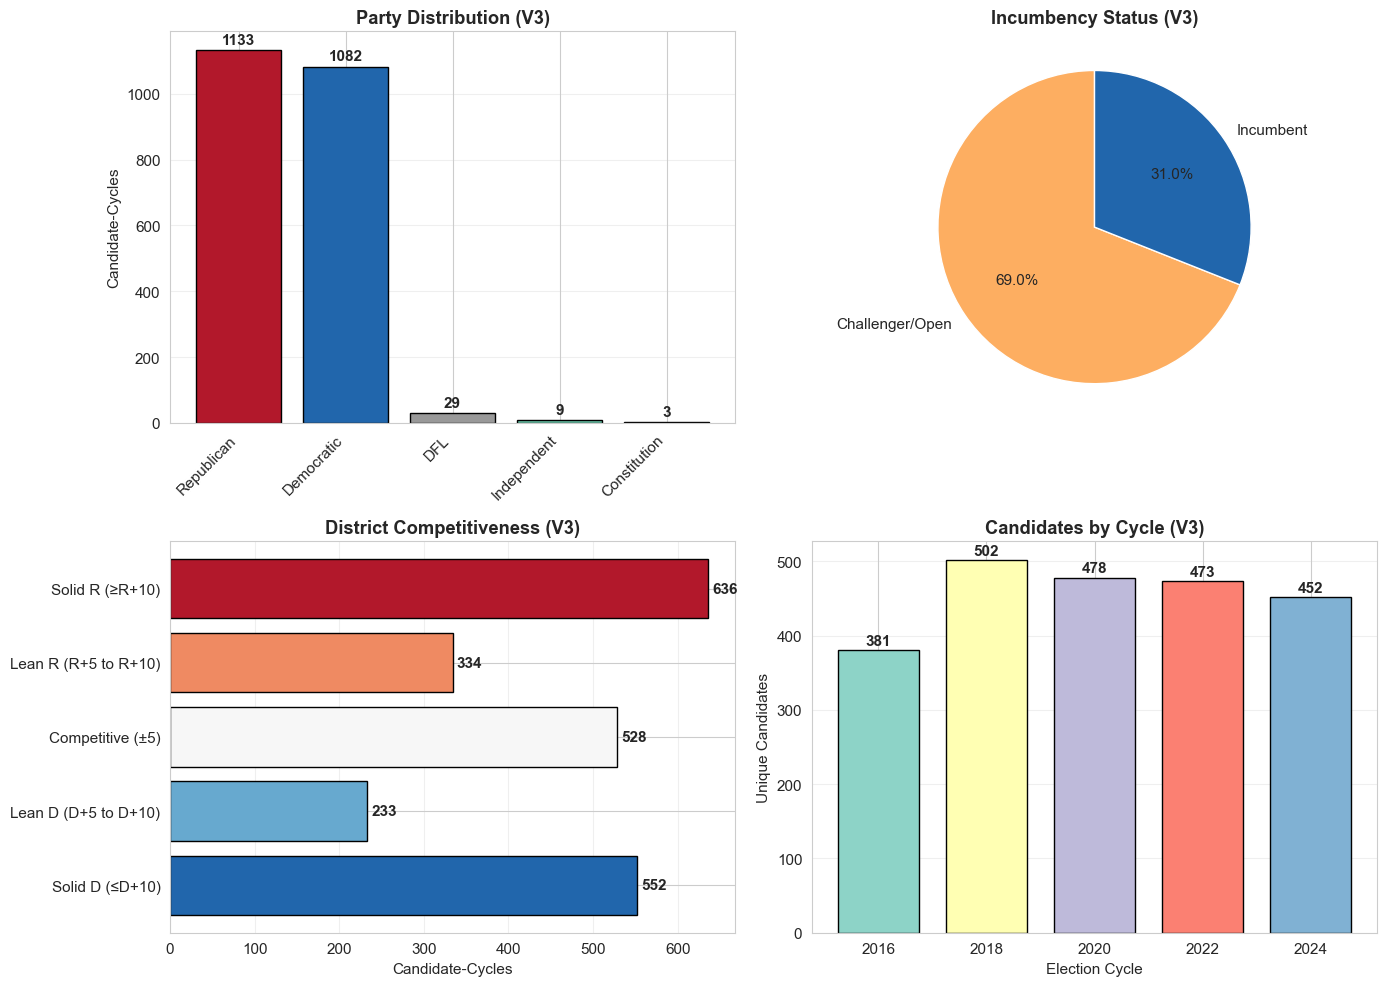


SUMMARY

* VARIATION 3 can be seen as a dataset for analyzing general election patterns
  • 970 unique House candidates
  • 2,286 candidate-cycles across 2016-2024
  • Removed idiosyncratic patterns (special elections, presidential runs)

* PARTY BALANCE: Roughly balanced between Democrats and Republicans
  • Democratic: 47.3%
  • Republican: 49.6%

* INCUMBENCY: 
  • Incumbents: 69.0%
  • Challengers/Open: 31.0%

* COMPETITIVENESS: 
  • Competitive (±5 PVI): ~23%



In [47]:
# =============================================================================
# SECTION 3: Dataset Composition & Variation Analysis
# =============================================================================

print("=" * 80)
print("DATASET COMPOSITION & VARIATION ANALYSIS FOR THE CLEANED DATASET (Variation 3)")
print("=" * 80)

# =============================================================================
# PART 1: Dataset Variation Comparison
# =============================================================================

print("\n" + "=" * 80)
print("PART 1: THREE DATASET VARIATIONS")
print("=" * 80)

# Load variation summary
variation_summary = pd.read_csv(data_dir / 'variation_summary.csv')
exclusions = json.load(open(data_dir / 'exclusion_lists.json'))

print("\n3 progressively filtered datasets to isolate general election patterns:\n")
print(variation_summary.to_string(index=False))

print("\nImpact of Exclusions:")
print(f"   V1 → V2: Removed {exclusions['statistics']['revisions_excluded_v2']:,} revisions")
print(f"            ({exclusions['statistics']['special_election_candidate_cycles']} special election candidate-cycles)")
print(f"   V2 → V3: Removed {exclusions['statistics']['revisions_excluded_v3']:,} revisions")
print(f"            ({exclusions['statistics']['presidential_candidates']} presidential candidates)")
print(f"   Total:   Excluded {exclusions['statistics']['revisions_excluded_v2'] + exclusions['statistics']['revisions_excluded_v3']:,} revisions (3.5% of V1)")

# =============================================================================
# PART 2: What Was Excluded and Why
# =============================================================================

print("\n" + "=" * 80)
print("PART 2: EXCLUSION ANALYSIS")
print("=" * 80)

# Load exclusion details
special_elections_df = pd.DataFrame(exclusions['special_elections'])
presidential_candidates = exclusions['presidential_candidates']

# 2A: Special Elections
print("\n2A. SPECIAL ELECTIONS EXCLUDED")
print("-" * 80)
print(f"Total: {len(special_elections_df)} candidate-cycles in {special_elections_df['election_cycle'].nunique()} cycles")
print()
print("Reason for exclusion: Special elections occur at irregular times (not November general elections),")
print("creating idiosyncratic attention spikes unaligned with general election cycles.")
print()

# Show distribution by cycle
print("Distribution by cycle:")
special_by_cycle = special_elections_df.groupby('election_cycle').size().sort_index()
for cycle, count in special_by_cycle.items():
    bar = "█" * (count // 2)
    print(f"   {cycle}: {count:2d} candidate-cycles {bar}")

print("\nExamples of excluded special election candidates:")
for i, row in special_elections_df.head(8).iterrows():
    district = row['district'] if pd.notna(row['district']) else 'AL'
    print(f"   • {row['candidate_name']:30s} ({row['state']}-{district}, {row['election_cycle']})")

# 2B: Presidential Candidates
print("\n2B. PRESIDENTIAL CANDIDATES EXCLUDED")
print("-" * 80)
print(f"Total: {len(presidential_candidates)} House members who ran for president")
print()
print("Reason for exclusion: Presidential candidates face:")
print("  • Different editing timespan (campaigns last 2+ years)")
print("  • National vs district-focused attention")
print("  • Elevated baseline activity that distorts general election patterns")
print()

print("Excluded presidential candidates:")
for page_title in sorted(presidential_candidates):
    name = page_title.replace('_', ' ').replace('(', '\n                                         (')
    print(f"   • {name}")

# =============================================================================
# PART 3: Final Dataset Characteristics (Variation 3)
# =============================================================================

print("\n" + "=" * 80)
print("PART 3: FINAL DATASET CHARACTERISTICS (Variation 3)")
print("=" * 80)
print()
print("Analyzing the composition of our CLEAN dataset (V3: No Special/No Presidential)")
print()

# Load V3 revisions data for analysis
# Need to filter base data to match V3
df_candidates_v3 = df_candidates[df_candidates['office'] == 'House'].copy()

# Filter out special elections
for _, row in special_elections_df.iterrows():
    mask = (df_candidates_v3['page_title'] == row['page_title']) & \
           (df_candidates_v3['election_cycle'] == row['election_cycle'])
    df_candidates_v3 = df_candidates_v3[~mask]

# Filter out presidential candidates
df_candidates_v3 = df_candidates_v3[~df_candidates_v3['page_title'].isin(presidential_candidates)]

# Filter to 2016-2024 cycles
df_candidates_v3 = df_candidates_v3[df_candidates_v3['election_cycle'].isin([2016, 2018, 2020, 2022, 2024])]

print(f"Total candidate-cycles in V3 (2016-2024): {len(df_candidates_v3):,}")
print(f"Unique candidates: {df_candidates_v3['page_title'].nunique():,}")
print()

# 3A: Party Distribution
print("3A. PARTY COMPOSITION")
print("-" * 80)
party_counts = df_candidates_v3['party'].value_counts()
total = len(df_candidates_v3)
print("Candidate-cycles by party:")
for party, count in party_counts.head(6).items():
    pct = 100 * count / total
    bar = "█" * int(pct / 2)
    print(f"   {party:15s}: {count:4d} ({pct:5.1f}%) {bar}")

# 3B: Incumbency Status
print("\n3B. INCUMBENCY STATUS")
print("-" * 80)
incumbency_counts = df_candidates_v3['candidate_was_incumbent'].value_counts()
print("Candidate-cycles by incumbency:")
for status, count in incumbency_counts.items():
    pct = 100 * count / total
    label = "Incumbent" if status else "Challenger/Open"
    bar = "█" * int(pct / 2)
    print(f"   {label:20s}: {count:4d} ({pct:5.1f}%) {bar}")

# 3C: Competitiveness (PVI)
print("\n3C. DISTRICT COMPETITIVENESS (by PVI)")
print("-" * 80)
print("Cook Partisan Voting Index: How much district leans R+ or D+ compared to nation")
print()

# Categorize by PVI
df_candidates_v3_copy = df_candidates_v3.copy()
df_candidates_v3_copy['pvi_category'] = pd.cut(
    df_candidates_v3_copy['pvi_numeric'],
    bins=[-100, -10, -5, 5, 10, 100],
    labels=['Solid D (≤D+10)', 'Lean D (D+5 to D+10)', 'Competitive (±5)', 'Lean R (R+5 to R+10)', 'Solid R (≥R+10)']
)

pvi_counts = df_candidates_v3_copy['pvi_category'].value_counts().sort_index()
pvi_total = pvi_counts.sum()

print("District categories:")
for category, count in pvi_counts.items():
    pct = 100 * count / pvi_total
    bar = "█" * int(pct / 2)
    print(f"   {str(category):25s}: {count:4d} ({pct:5.1f}%) {bar}")

missing_pvi = df_candidates_v3_copy['pvi_numeric'].isna().sum()
if missing_pvi > 0:
    print(f"   {'Missing PVI data':25s}: {missing_pvi:4d} ({100*missing_pvi/total:5.1f}%)")

# 3D: Temporal Coverage
print("\n3D. TEMPORAL COVERAGE")
print("-" * 80)
cycle_counts = df_candidates_v3.groupby('election_cycle')['page_title'].nunique().sort_index()
print("Unique candidates by cycle:")
for cycle, count in cycle_counts.items():
    election_type = ELECTION_METADATA.get(cycle, {}).get('type', 'unknown')
    bar = "█" * (count // 20)
    print(f"   {cycle} ({election_type:12s}): {count:3d} candidates {bar}")

# 3E: Geographic Coverage
print("\n3E. GEOGRAPHIC COVERAGE")
print("-" * 80)
state_counts = df_candidates_v3.groupby('state')['page_title'].nunique().sort_values(ascending=False)
print(f"Candidates from {len(state_counts)} states")
print("\nTop 10 states:")
for i, (state, count) in enumerate(state_counts.head(10).items(), 1):
    print(f"   {i:2d}. {state:15s}: {count:3d} candidates")

# =============================================================================
# PART 4: Visual Summary
# =============================================================================

print("\n" + "=" * 80)
print("PART 4: VISUAL SUMMARY")
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Party Distribution
ax = axes[0, 0]
party_plot = party_counts.head(5)
colors_party = {'Democratic': '#2166ac', 'Republican': '#b2182b', 'Libertarian': '#fdae61',
                'Independent': '#66c2a5', 'Green': '#5aae61'}
plot_colors = [colors_party.get(p, '#999999') for p in party_plot.index]
ax.bar(range(len(party_plot)), party_plot.values, color=plot_colors, edgecolor='black')
ax.set_xticks(range(len(party_plot)))
ax.set_xticklabels(party_plot.index, rotation=45, ha='right')
ax.set_ylabel('Candidate-Cycles')
ax.set_title('Party Distribution (V3)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(party_plot.values):
    ax.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Incumbency
ax = axes[0, 1]
incumbency_plot = df_candidates_v3['candidate_was_incumbent'].value_counts()
labels = ['Challenger/Open', 'Incumbent']
colors = ['#fdae61', '#2166ac']
wedges, texts, autotexts = ax.pie(incumbency_plot.values, labels=labels, autopct='%1.1f%%',
                                    colors=colors, startangle=90)
ax.set_title('Incumbency Status (V3)', fontweight='bold')

# Plot 3: Competitiveness (PVI)
ax = axes[1, 0]
pvi_plot_data = df_candidates_v3_copy['pvi_category'].value_counts().sort_index()
colors_pvi = ['#2166ac', '#67a9cf', '#f7f7f7', '#ef8a62', '#b2182b']
ax.barh(range(len(pvi_plot_data)), pvi_plot_data.values, color=colors_pvi, edgecolor='black')
ax.set_yticks(range(len(pvi_plot_data)))
ax.set_yticklabels([str(x)[:20] for x in pvi_plot_data.index])
ax.set_xlabel('Candidate-Cycles')
ax.set_title('District Competitiveness (V3)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(pvi_plot_data.values):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold')

# Plot 4: Temporal Coverage
ax = axes[1, 1]
cycle_plot = df_candidates_v3.groupby('election_cycle')['page_title'].nunique().sort_index()
colors_temporal = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3']
ax.bar(cycle_plot.index, cycle_plot.values, color=colors_temporal, edgecolor='black', width=1.5)
ax.set_xlabel('Election Cycle')
ax.set_ylabel('Unique Candidates')
ax.set_title('Candidates by Cycle (V3)', fontweight='bold')
ax.set_xticks(cycle_plot.index)
ax.grid(axis='y', alpha=0.3)
for x, y in zip(cycle_plot.index, cycle_plot.values):
    ax.text(x, y + 3, str(y), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# Summary
# =============================================================================

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print()
print("* VARIATION 3 can be seen as a dataset for analyzing general election patterns")
print(f"  • {df_candidates_v3['page_title'].nunique():,} unique House candidates")
print(f"  • {len(df_candidates_v3):,} candidate-cycles across 2016-2024")
print(f"  • Removed idiosyncratic patterns (special elections, presidential runs)")
print()
print("* PARTY BALANCE: Roughly balanced between Democrats and Republicans")
print(f"  • Democratic: {100*party_counts.get('Democratic', 0)/total:.1f}%")
print(f"  • Republican: {100*party_counts.get('Republican', 0)/total:.1f}%")
print()
print("* INCUMBENCY: ")
print(f"  • Incumbents: {100*incumbency_counts.get(True, 0)/total:.1f}%")
print(f"  • Challengers/Open: {100*incumbency_counts.get(False, 0)/total:.1f}%")
print()
print("* COMPETITIVENESS: ")
print(f"  • Competitive (±5 PVI): ~{100*pvi_counts.get('Competitive (±5)', 0)/pvi_total:.0f}%")
print()
print("=" * 80)



## 4. Pre-Election Dynamics Analysis
Analyze editing behavior changes using 2-year non-overlapping cycles.

**Notation:**
- **W (Washout)**: 30 days after previous election (to exclude post-election info updates)
- **L (Pre-election window)**: 60 days before current election
- **Baseline**: (E_{y-2} + W, E_y - L]
- **Pre-election**: (E_y - L, E_y) - event window of interest

For each cycle, I only analyze pages where the candidate was running during that cycle.

In [6]:
# Define cycle parameters
WASHOUT_DAYS = 30  # W: days after previous election to exclude
PRE_ELECTION_DAYS = 200  # L: pre-election event window

print("Parameters:")
print(f"  W (Washout): {WASHOUT_DAYS} days after previous election")
print(f"  L (Pre-election window): {PRE_ELECTION_DAYS} days before election")

print("\n" + "="*80)
print("ANALYSIS PER CYCLE")
print("="*80)

# Analyze each cycle
cycle_results = []

for year in [2016, 2018, 2020, 2022, 2024]:
    # Get cycle windows
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    election_day = get_election_day(year)
    election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        # Fallback: use all pages
        pages_on_ballot = df_pages['page_title'].tolist()
    
    print(f"\n{year} {election_type.capitalize()} Election ({election_day})")
    print(f"  Pages on ballot: {len(pages_on_ballot)}")
    print(f"  Washout: {windows['washout'][0]} to {windows['washout'][1]}")
    print(f"  Baseline: {windows['baseline'][0]} to {windows['baseline'][1]}")
    print(f"  Pre-election: {windows['pre_election'][0]} to {windows['pre_election'][1]}")
    
    # Filter data for this cycle and on-ballot pages only
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    
    # Get baseline period data
    baseline_mask = (df_cycle['date'].dt.date >= windows['baseline'][0]) & \
                    (df_cycle['date'].dt.date <= windows['baseline'][1])
    baseline_data = df_cycle[baseline_mask]
    
    # Get pre-election period data
    pre_election_mask = (df_cycle['date'].dt.date >= windows['pre_election'][0]) & \
                        (df_cycle['date'].dt.date <= windows['pre_election'][1])
    pre_election_data = df_cycle[pre_election_mask]
    
    # Compute average edits per page per day for each window
    if len(baseline_data) > 0:
        baseline_avg = baseline_data.groupby('date')['num_edits'].mean().mean()
    else:
        baseline_avg = 0
    
    if len(pre_election_data) > 0:
        pre_election_avg = pre_election_data.groupby('date')['num_edits'].mean().mean()
    else:
        pre_election_avg = 0
    
    # Calculate change
    if baseline_avg > 0:
        pct_change = ((pre_election_avg - baseline_avg) / baseline_avg) * 100
    else:
        pct_change = 0
    
    print(f"  Baseline avg: {baseline_avg:.3f} edits/page/day")
    print(f"  Pre-election avg: {pre_election_avg:.3f} edits/page/day")
    print(f"  Change: {pct_change:+.1f}%")
    
    cycle_results.append({
        'year': year,
        'type': election_type,
        'pages_on_ballot': len(pages_on_ballot),
        'baseline_avg': baseline_avg,
        'pre_election_avg': pre_election_avg,
        'pct_change': pct_change,
        'windows': windows
    })

# Convert to DataFrame for easy analysis
df_cycle_results = pd.DataFrame(cycle_results)
print("\n" + "="*80)
print("SUMMARY ACROSS ALL CYCLES")
print("="*80)
print(df_cycle_results[['year', 'type', 'pages_on_ballot', 'baseline_avg', 'pre_election_avg', 'pct_change']])

Parameters:
  W (Washout): 30 days after previous election
  L (Pre-election window): 200 days before election

ANALYSIS PER CYCLE

2016 Presidential Election (2016-11-08)
  Pages on ballot: 84
  Washout: 2014-11-04 to 2014-12-04
  Baseline: 2014-12-05 to 2016-04-22
  Pre-election: 2016-04-23 to 2016-11-07
  Baseline avg: 3.295 edits/page/day
  Pre-election avg: 2.884 edits/page/day
  Change: -12.5%

2018 Midterm Election (2018-11-06)
  Pages on ballot: 112
  Washout: 2016-11-08 to 2016-12-08
  Baseline: 2016-12-09 to 2018-04-20
  Pre-election: 2018-04-21 to 2018-11-05
  Baseline avg: 2.098 edits/page/day
  Pre-election avg: 2.154 edits/page/day
  Change: +2.7%

2020 Presidential Election (2020-11-03)
  Pages on ballot: 75
  Washout: 2018-11-06 to 2018-12-06
  Baseline: 2018-12-07 to 2020-04-17
  Pre-election: 2020-04-18 to 2020-11-02
  Baseline avg: 2.475 edits/page/day
  Pre-election avg: 2.113 edits/page/day
  Change: -14.6%

2022 Midterm Election (2022-11-08)
  Pages on ballot: 97


Y-axis range across all cycles: [0.00, 22.16]



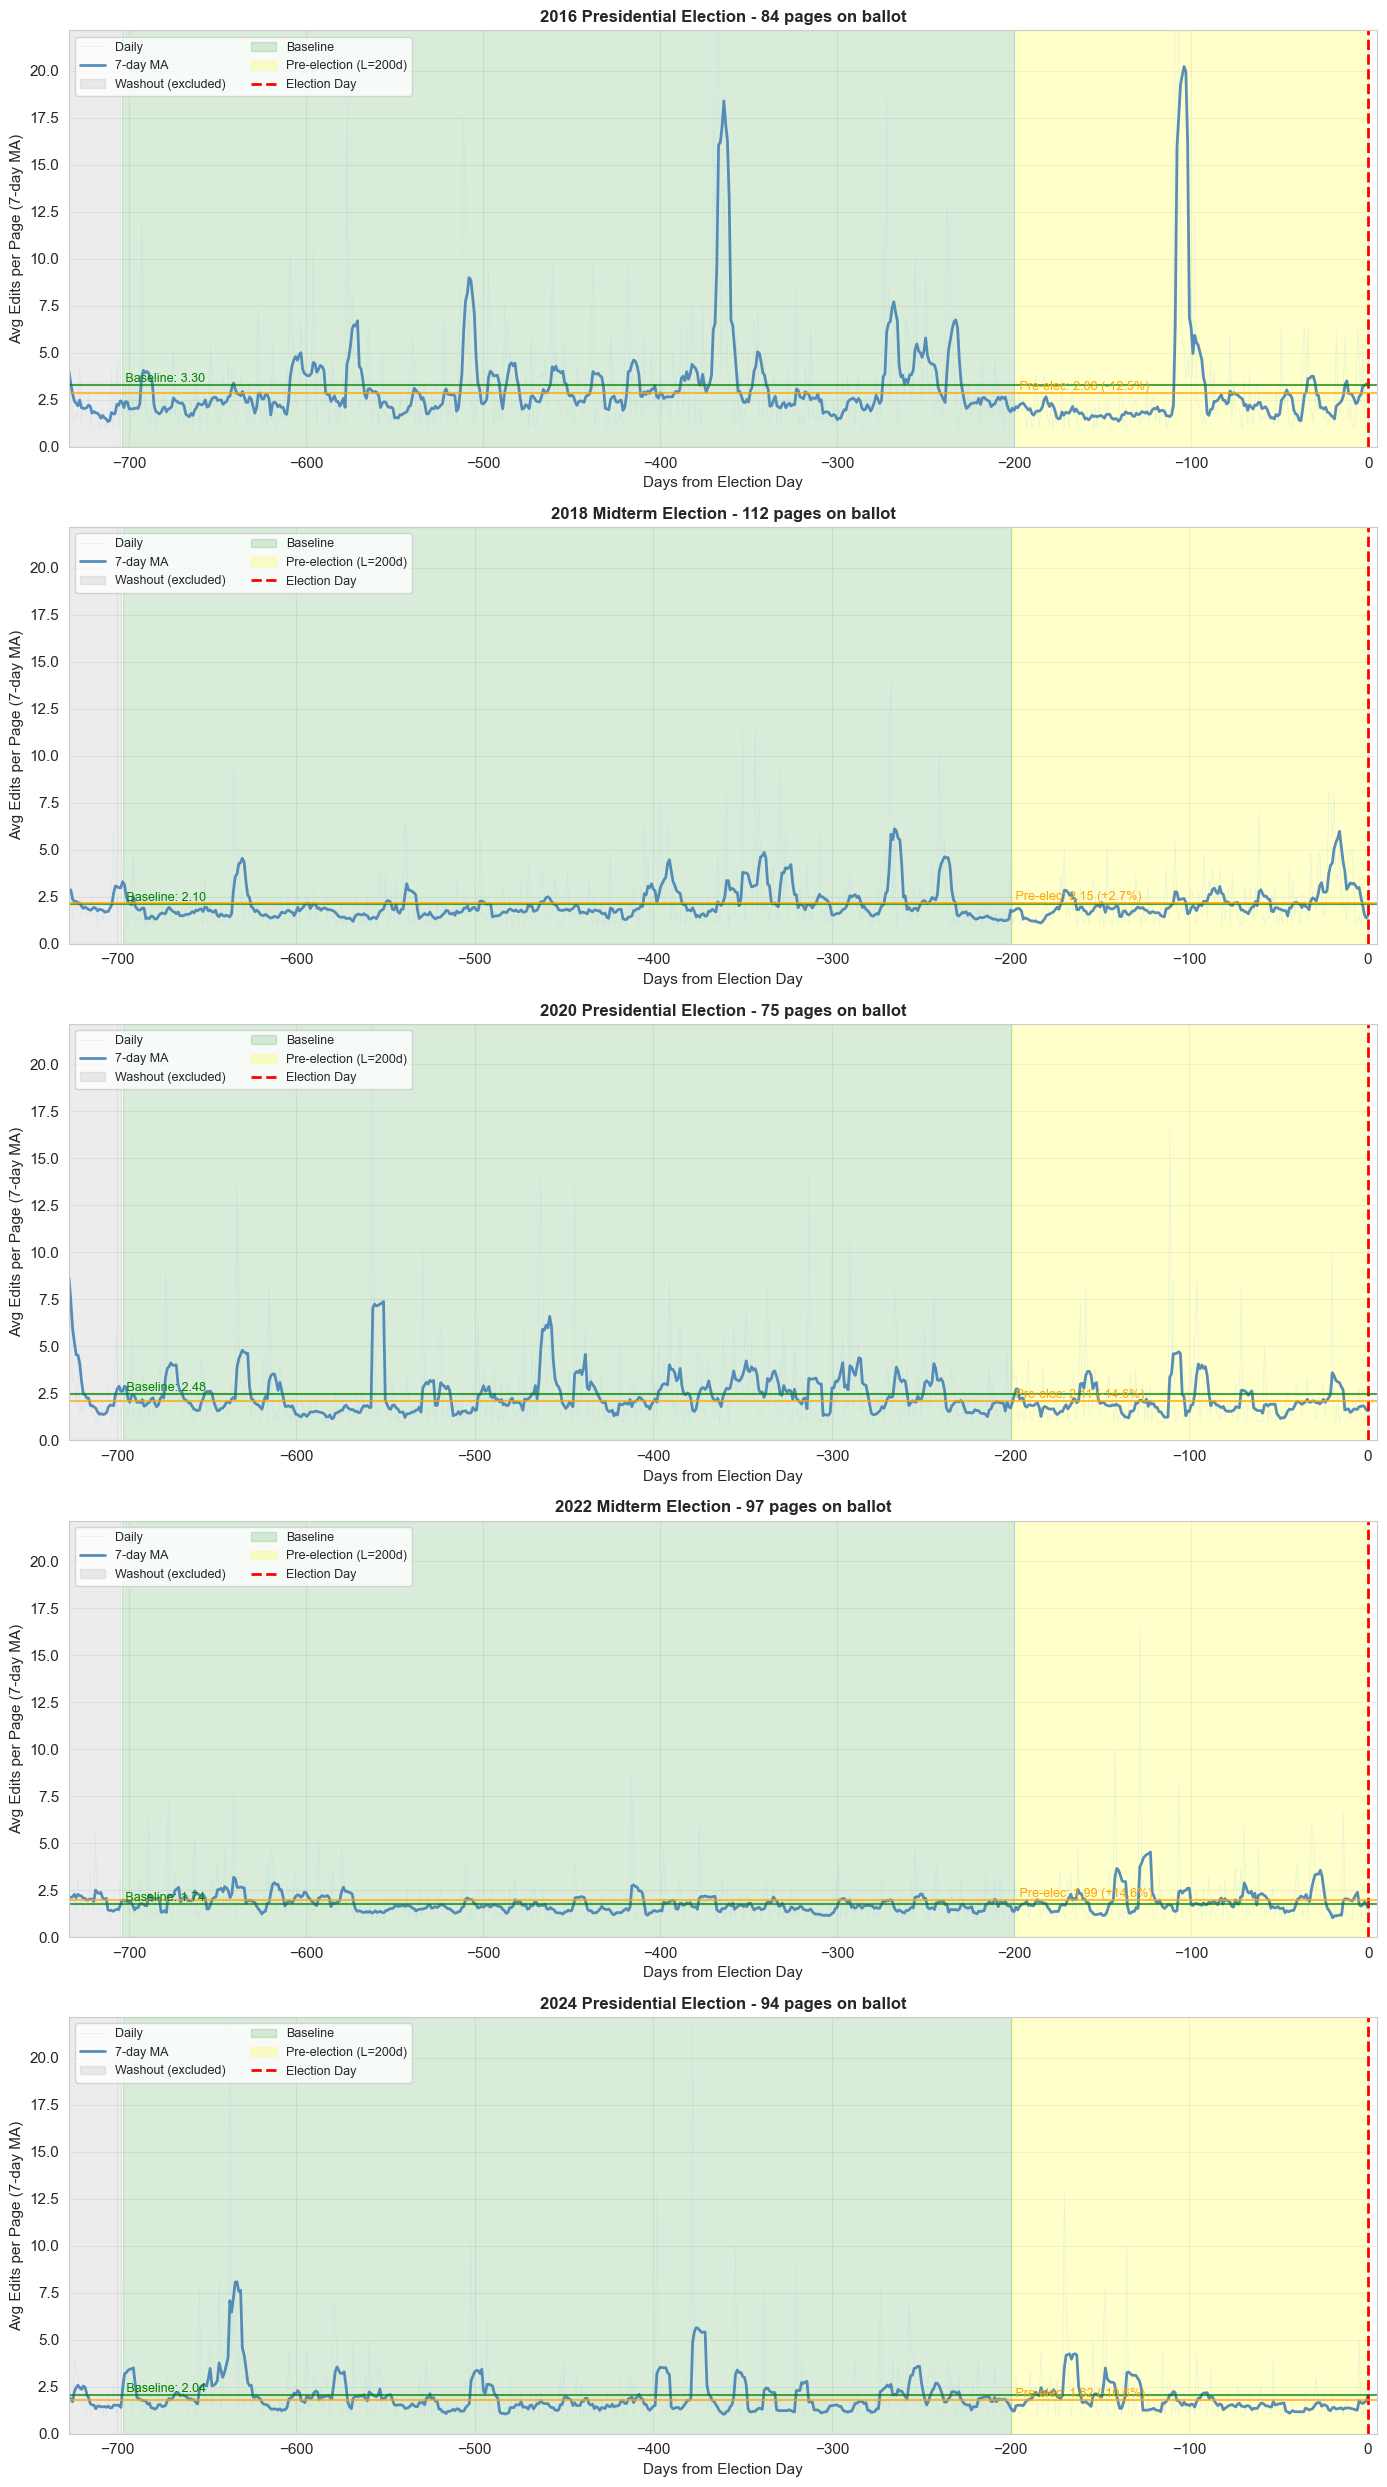


Key:
- Washout (gray): Post-election period excluded from baseline
- Baseline (green): 'Normal' editing period for comparison
- Pre-election (yellow): Event window of interest (L=200 days)
- Horizontal lines show average editing rates for baseline and pre-election windows
- All graphs use the same y-axis scale for easy comparison


In [7]:
# Visualize event study
# For each cycle, show editing pattern with 2-year cycles marked

fig, axes = plt.subplots(len(cycle_results), 1, figsize=(14, 5*len(cycle_results)))
if len(cycle_results) == 1:
    axes = [axes]

# First pass: calculate global y-axis range across all cycles
global_max = 0
global_min = float('inf')

for cycle_info in cycle_results:
    year = cycle_info['year']
    windows = cycle_info['windows']
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        pages_on_ballot = df_pages['page_title'].tolist()
    
    # Filter to cycle dates and on-ballot pages
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    cycle_mask = (df_cycle['date'].dt.date >= windows['cycle_start']) & \
                 (df_cycle['date'].dt.date <= windows['cycle_end'])
    df_cycle = df_cycle[cycle_mask]
    
    # Aggregate: average edits per page per day
    daily_cycle = df_cycle.groupby('date')['num_edits'].mean().reset_index()
    
    if len(daily_cycle) > 0:
        daily_cycle.columns = ['date', 'avg_edits_per_page']
        daily_cycle['ma7'] = daily_cycle['avg_edits_per_page'].rolling(window=7, min_periods=1).mean()
        
        global_max = max(global_max, daily_cycle['ma7'].max())
        global_min = min(global_min, daily_cycle['ma7'].min())

# Add some padding to the y-axis range
y_padding = (global_max - global_min) * 0.1
y_min = max(0, global_min - y_padding)  # Don't go below 0
y_max = global_max + y_padding

print(f"Y-axis range across all cycles: [{y_min:.2f}, {y_max:.2f}]\n")

# Second pass: create the plots with consistent y-axis
for i, cycle_info in enumerate(cycle_results):
    year = cycle_info['year']
    windows = cycle_info['windows']
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        pages_on_ballot = df_pages['page_title'].tolist()
    
    # Filter to cycle dates and on-ballot pages
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    cycle_mask = (df_cycle['date'].dt.date >= windows['cycle_start']) & \
                 (df_cycle['date'].dt.date <= windows['cycle_end'])
    df_cycle = df_cycle[cycle_mask]
    
    # Aggregate: average edits per page per day
    daily_cycle = df_cycle.groupby('date')['num_edits'].mean().reset_index()
    daily_cycle.columns = ['date', 'avg_edits_per_page']
    
    # Add 7-day moving average
    daily_cycle['ma7'] = daily_cycle['avg_edits_per_page'].rolling(window=7, min_periods=1).mean()
    
    # Convert dates to days from election
    election_day = windows['election_day'][0]
    daily_cycle['days_from_election'] = (daily_cycle['date'].dt.date - election_day).apply(lambda x: x.days)
    
    ax = axes[i]
    
    # Plot the data
    ax.plot(daily_cycle['days_from_election'], daily_cycle['avg_edits_per_page'], 
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
    ax.plot(daily_cycle['days_from_election'], daily_cycle['ma7'], 
            linewidth=2, alpha=0.9, color='steelblue', label='7-day MA')
    
    # Mark windows
    baseline_start_days = (windows['baseline'][0] - election_day).days
    baseline_end_days = (windows['baseline'][1] - election_day).days
    pre_election_start_days = (windows['pre_election'][0] - election_day).days
    pre_election_end_days = (windows['pre_election'][1] - election_day).days
    washout_start_days = (windows['washout'][0] - election_day).days
    washout_end_days = (windows['washout'][1] - election_day).days
    
    # Shade the windows
    ax.axvspan(washout_start_days, washout_end_days, alpha=0.15, color='gray', label='Washout (excluded)')
    ax.axvspan(baseline_start_days, baseline_end_days, alpha=0.15, color='green', label=f'Baseline')
    ax.axvspan(pre_election_start_days, pre_election_end_days, alpha=0.2, color='yellow', label=f'Pre-election (L={PRE_ELECTION_DAYS}d)')
    
    # Mark election day
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Election Day')
    
    # Add horizontal line for baseline average
    ax.axhline(cycle_info['baseline_avg'], color='green', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.text(baseline_start_days, cycle_info['baseline_avg'], 
            f" Baseline: {cycle_info['baseline_avg']:.2f}", 
            fontsize=9, color='green', va='bottom')
    
    # Add horizontal line for pre-election average
    ax.axhline(cycle_info['pre_election_avg'], color='orange', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.text(pre_election_start_days, cycle_info['pre_election_avg'], 
            f" Pre-elec: {cycle_info['pre_election_avg']:.2f} ({cycle_info['pct_change']:+.1f}%)", 
            fontsize=9, color='orange', va='bottom')
    
    # Formatting
    ax.set_title(f"{year} {cycle_info['type'].capitalize()} Election - {cycle_info['pages_on_ballot']} pages on ballot", 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Days from Election Day', fontsize=11)
    ax.set_ylabel('Avg Edits per Page (7-day MA)', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show the full cycle
    cycle_start_days = (windows['cycle_start'] - election_day).days
    ax.set_xlim(cycle_start_days, 5)  # Show a bit past election day
    
    # Set consistent y-axis across all plots
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

print("\nKey:")
print("- Washout (gray): Post-election period excluded from baseline")
print("- Baseline (green): 'Normal' editing period for comparison")
print(f"- Pre-election (yellow): Event window of interest (L={PRE_ELECTION_DAYS} days)")
print("- Horizontal lines show average editing rates for baseline and pre-election windows")
print("- All graphs use the same y-axis scale for easy comparison")

A spike due to an external event. 

* Date: 2023-10-24
* Days from election: -378
* Total edits: 64
* Pages edited: 1
* Avg edits per page: 64.00

Pages edited on 2023-10-24: - Tom Emmer: 64 edits by 38 editors

Tom Emmer was nominated by House Republicans as Speaker of the House candidate (following Kevin McCarthy's ouster on October 3, 2023). Emmer withdrew his candidacy later the same day due to insufficient support.

## 5. Interpretation and diagnostics
Positive % changes indicate pre-election editing spikes; negative changes indicate lower activity than baseline.

### Abnormal spikes can be due to
- Data collection artifact (e.g., some pages were created/matched late)
- Real editing pattern (e.g., a specific event that triggered edits)
- Sampling issue (e.g., certain high-profile candidates only entered the race later, or wrong page matches)

## 6. Editor Partisan Classification

Classify editors by their editing patterns:
- **Dem-only editors**: Non-bot editors who only edit Democratic candidate pages
- **Rep-only editors**: Non-bot editors who only edit Republican candidate pages  
- **Cross-party editors**: Non-bot editors who edit both Democratic and Republican pages
- **Bot editors**: Accounts in Wikipedia's "bot" user group

Note. An editor who only edits Dem pages in 2016 but edits Rep pages in 2020 would be classified as "Dem-only" in 2016, "Rep-only" in 2020, but "Cross-party" in the 10-year aggregate.


### 6.1 Editor partisan classification

In [8]:
# Load full revision data
df_revisions = pd.read_csv(data_dir / 'all_revisions.csv', parse_dates=['timestamp'])

# Create page-to-party mapping from roster
page_party_map = {}
for page in roster_data['pages']:
    title = page['title']
    party = page.get('primary_party', 'Unknown')
    page_party_map[title] = party

# Add party column to revisions
df_revisions['party'] = df_revisions['page_title'].map(page_party_map)

print(f"Total revisions: {len(df_revisions):,}")
print(f"Unique editors: {df_revisions['user'].nunique():,}")
print(f"\nEdit distribution by party:")
print(df_revisions['party'].value_counts())

# =============================================================================
# FUNCTION: Classify editors for a given subset of data
# =============================================================================

def classify_editors(df_subset):
    """
    Classify editors based on their editing patterns.
    
    Returns:
        Dictionary with counts for each category
    """
    # Separate bots from non-bots
    df_bots = df_subset[df_subset['is_bot'] == True]
    df_non_bots = df_subset[df_subset['is_bot'] == False]
    
    bot_editors = df_bots['user'].unique()
    
    # For non-bots, find which parties each editor has edited
    editor_parties = df_non_bots.groupby('user')['party'].apply(set).to_dict()
    
    dem_only = []
    rep_only = []
    cross_party = []
    other_only = []  # Editors who only edit non-Dem/Rep pages
    
    for editor, parties in editor_parties.items():
        has_dem = 'Democratic' in parties
        has_rep = 'Republican' in parties
        
        if has_dem and has_rep:
            cross_party.append(editor)
        elif has_dem and not has_rep:
            dem_only.append(editor)
        elif has_rep and not has_dem:
            rep_only.append(editor)
        else:
            other_only.append(editor)
    
    return {
        'dem_only': len(dem_only),
        'rep_only': len(rep_only),
        'cross_party': len(cross_party),
        'bot': len(bot_editors),
        'other_only': len(other_only),
        'total_non_bot': len(dem_only) + len(rep_only) + len(cross_party) + len(other_only),
        'total': len(dem_only) + len(rep_only) + len(cross_party) + len(other_only) + len(bot_editors),
        # Also return the actual editor lists for further analysis
        '_dem_only_editors': set(dem_only),
        '_rep_only_editors': set(rep_only),
        '_cross_party_editors': set(cross_party),
        '_bot_editors': set(bot_editors)
    }

# =============================================================================
# ANALYSIS BY CYCLE
# =============================================================================

print("\n" + "="*80)
print("EDITOR CLASSIFICATION BY 2-YEAR CYCLE")
print("="*80)

cycle_results = []

for year in [2016, 2018, 2020, 2022, 2024]:
    # Get cycle windows
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    
    # Filter revisions to this cycle
    cycle_mask = (df_revisions['timestamp'].dt.date >= windows['cycle_start']) & \
                 (df_revisions['timestamp'].dt.date <= windows['cycle_end'])
    df_cycle = df_revisions[cycle_mask]
    
    # Classify editors
    results = classify_editors(df_cycle)
    results['year'] = year
    results['election_type'] = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    cycle_results.append(results)
    
    print(f"\n{year} {results['election_type'].capitalize()} Cycle ({windows['cycle_start']} to {windows['cycle_end']})")
    print(f"  Total unique editors: {results['total']:,}")
    print(f"  ├── Bot editors: {results['bot']:,} ({100*results['bot']/results['total']:.1f}%)")
    print(f"  └── Non-bot editors: {results['total_non_bot']:,}")
    print(f"      ├── Dem-only: {results['dem_only']:,} ({100*results['dem_only']/results['total_non_bot']:.1f}%)")
    print(f"      ├── Rep-only: {results['rep_only']:,} ({100*results['rep_only']/results['total_non_bot']:.1f}%)")
    print(f"      ├── Cross-party: {results['cross_party']:,} ({100*results['cross_party']/results['total_non_bot']:.1f}%)")
    if results['other_only'] > 0:
        print(f"      └── Other-only: {results['other_only']:,} ({100*results['other_only']/results['total_non_bot']:.1f}%)")

# =============================================================================
# 10-YEAR AGGREGATE (computed fresh, NOT summed)
# =============================================================================

print("\n" + "="*80)
print("10-YEAR AGGREGATE (2015-2024)")
print("="*80)

# Classify over the entire period
results_all = classify_editors(df_revisions)

print(f"\nTotal unique editors across all years: {results_all['total']:,}")
print(f"  ├── Bot editors: {results_all['bot']:,} ({100*results_all['bot']/results_all['total']:.1f}%)")
print(f"  └── Non-bot editors: {results_all['total_non_bot']:,}")
print(f"      ├── Dem-only: {results_all['dem_only']:,} ({100*results_all['dem_only']/results_all['total_non_bot']:.1f}%)")
print(f"      ├── Rep-only: {results_all['rep_only']:,} ({100*results_all['rep_only']/results_all['total_non_bot']:.1f}%)")
print(f"      ├── Cross-party: {results_all['cross_party']:,} ({100*results_all['cross_party']/results_all['total_non_bot']:.1f}%)")
if results_all['other_only'] > 0:
    print(f"      └── Other-only: {results_all['other_only']:,} ({100*results_all['other_only']/results_all['total_non_bot']:.1f}%)")
    

Total revisions: 138,717
Unique editors: 28,652

Edit distribution by party:
party
Republican    76066
Democratic    62651
Name: count, dtype: int64

EDITOR CLASSIFICATION BY 2-YEAR CYCLE

2016 Presidential Cycle (2014-11-05 to 2016-11-08)
  Total unique editors: 6,410
  ├── Bot editors: 31 (0.5%)
  └── Non-bot editors: 6,379
      ├── Dem-only: 2,129 (33.4%)
      ├── Rep-only: 3,675 (57.6%)
      ├── Cross-party: 575 (9.0%)

2018 Midterm Cycle (2016-11-09 to 2018-11-06)
  Total unique editors: 7,322
  ├── Bot editors: 30 (0.4%)
  └── Non-bot editors: 7,292
      ├── Dem-only: 2,526 (34.6%)
      ├── Rep-only: 4,012 (55.0%)
      ├── Cross-party: 754 (10.3%)

2020 Presidential Cycle (2018-11-07 to 2020-11-03)
  Total unique editors: 7,669
  ├── Bot editors: 36 (0.5%)
  └── Non-bot editors: 7,633
      ├── Dem-only: 3,271 (42.9%)
      ├── Rep-only: 3,435 (45.0%)
      ├── Cross-party: 927 (12.1%)

2022 Midterm Cycle (2020-11-04 to 2022-11-08)
  Total unique editors: 6,430
  ├── Bot ed

SUMMARY TABLE: Editor Counts by Category
               Dem-only  Rep-only  Cross-party  Bot  Total
Period                                                    
2016 (pres)        2129      3675          575   31   6410
2018 (midt)        2526      4012          754   30   7322
2020 (pres)        3271      3435          927   36   7669
2022 (midt)        2718      2904          774   34   6430
2024 (pres)        2150      2188          679   32   5049
10-Year Total     11093     14373         3121   65  28652

SUMMARY TABLE: Percentages
(Dem-only, Rep-only, Cross-party as % of non-bot; Bot as % of total)
               Dem-only  Rep-only  Cross-party  Bot
Period                                             
2016 (pres)        33.4      57.6          9.0  0.5
2018 (midt)        34.6      55.0         10.3  0.4
2020 (pres)        42.9      45.0         12.1  0.5
2022 (midt)        42.5      45.4         12.1  0.5
2024 (pres)        42.9      43.6         13.5  0.6
10-Year Total      38.8   

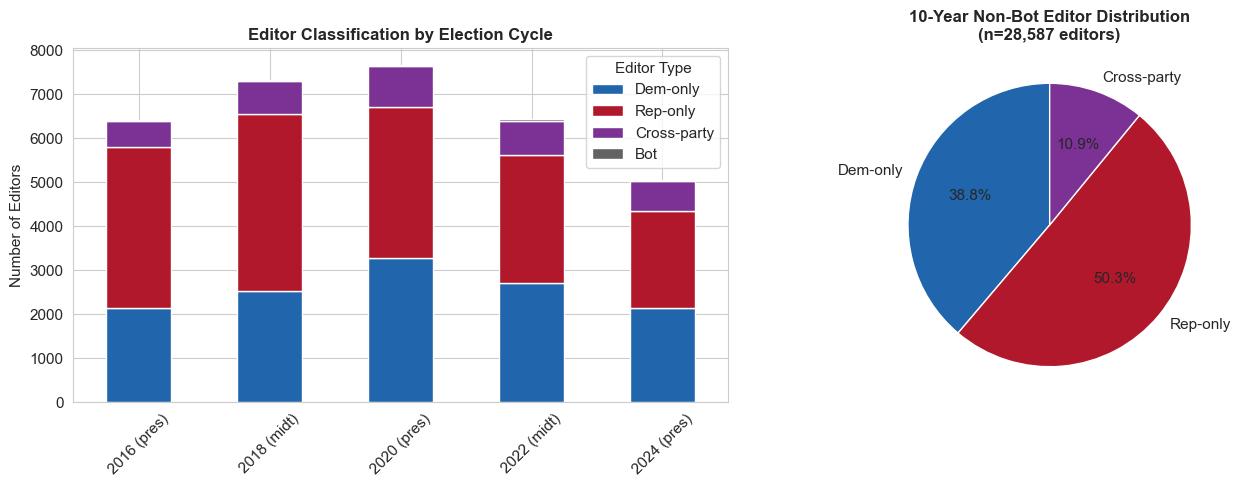

In [9]:
# =============================================================================
# SUMMARY TABLE AND VISUALIZATION
# =============================================================================

# Create summary DataFrame
summary_data = []
for r in cycle_results:
    summary_data.append({
        'Period': f"{r['year']} ({r['election_type'][:4]})",
        'Dem-only': r['dem_only'],
        'Rep-only': r['rep_only'],
        'Cross-party': r['cross_party'],
        'Bot': r['bot'],
        'Total': r['total']
    })

# Add 10-year aggregate
summary_data.append({
    'Period': '10-Year Total',
    'Dem-only': results_all['dem_only'],
    'Rep-only': results_all['rep_only'],
    'Cross-party': results_all['cross_party'],
    'Bot': results_all['bot'],
    'Total': results_all['total']
})

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('Period')

print("="*80)
print("SUMMARY TABLE: Editor Counts by Category")
print("="*80)
print(df_summary.to_string())

# Calculate percentages (of non-bot editors)
df_pct = df_summary.copy()
for col in ['Dem-only', 'Rep-only', 'Cross-party']:
    df_pct[col] = (df_summary[col] / (df_summary['Total'] - df_summary['Bot']) * 100).round(1)
df_pct['Bot'] = (df_summary['Bot'] / df_summary['Total'] * 100).round(1)
df_pct = df_pct[['Dem-only', 'Rep-only', 'Cross-party', 'Bot']]

print("\n" + "="*80)
print("SUMMARY TABLE: Percentages")
print("(Dem-only, Rep-only, Cross-party as % of non-bot; Bot as % of total)")
print("="*80)
print(df_pct.to_string())

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked bar chart of editor counts by cycle
cycle_df = df_summary.iloc[:-1].copy()  # Exclude 10-year total
cycle_df[['Dem-only', 'Rep-only', 'Cross-party', 'Bot']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2166ac', '#b2182b', '#7b3294', '#636363']
)
axes[0].set_title('Editor Classification by Election Cycle', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Editors')
axes[0].legend(title='Editor Type', loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Pie chart for 10-year aggregate (non-bot only)
non_bot_data = [results_all['dem_only'], results_all['rep_only'], results_all['cross_party']]
non_bot_labels = ['Dem-only', 'Rep-only', 'Cross-party']
colors = ['#2166ac', '#b2182b', '#7b3294']

axes[1].pie(non_bot_data, labels=non_bot_labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'10-Year Non-Bot Editor Distribution\n(n={results_all["total_non_bot"]:,} editors)', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 6.2 Edit counts by editor type

In [10]:
print("\n" + "="*80)
print("EDIT COUNTS BY EDITOR TYPE (10-year aggregate)")
print("="*80)

# Count edits by editor type
dem_only_edits = df_revisions[df_revisions['user'].isin(results_all['_dem_only_editors'])]['user'].count()
rep_only_edits = df_revisions[df_revisions['user'].isin(results_all['_rep_only_editors'])]['user'].count()
cross_party_edits = df_revisions[df_revisions['user'].isin(results_all['_cross_party_editors'])]['user'].count()
bot_edits = df_revisions[df_revisions['is_bot'] == True]['user'].count()

total_edits = len(df_revisions)
other_edits = total_edits - dem_only_edits - rep_only_edits - cross_party_edits - bot_edits

print(f"\nTotal edits: {total_edits:,}")
print(f"  Dem-only editors: {dem_only_edits:,} edits ({100*dem_only_edits/total_edits:.1f}%)")
print(f"  Rep-only editors: {rep_only_edits:,} edits ({100*rep_only_edits/total_edits:.1f}%)")
print(f"  Cross-party editors: {cross_party_edits:,} edits ({100*cross_party_edits/total_edits:.1f}%)")
print(f"  Bot editors: {bot_edits:,} edits ({100*bot_edits/total_edits:.1f}%)")
if other_edits > 0:
    print(f"  Other: {other_edits:,} edits ({100*other_edits/total_edits:.1f}%)")

# Average edits per editor
print(f"\nAverage edits per editor:")
print(f"  Dem-only: {dem_only_edits/results_all['dem_only']:.1f} edits/editor")
print(f"  Rep-only: {rep_only_edits/results_all['rep_only']:.1f} edits/editor")
print(f"  Cross-party: {cross_party_edits/results_all['cross_party']:.1f} edits/editor")
print(f"  Bot: {bot_edits/results_all['bot']:.1f} edits/editor")


EDIT COUNTS BY EDITOR TYPE (10-year aggregate)

Total edits: 138,717
  Dem-only editors: 21,758 edits (15.7%)
  Rep-only editors: 28,589 edits (20.6%)
  Cross-party editors: 79,644 edits (57.4%)
  Bot editors: 8,726 edits (6.3%)

Average edits per editor:
  Dem-only: 2.0 edits/editor
  Rep-only: 2.0 edits/editor
  Cross-party: 25.5 edits/editor
  Bot: 134.2 edits/editor


### 6.3 Smoothed Partisan Lean Measure (smoothing with strong beta shrinkage towards (0,0))

Define a continuous partisan lean score for each editor:

$$s_{e,y} = \frac{D_{e,y} - R_{e,y}}{D_{e,y} + R_{e,y} + 2\alpha}$$

Where:
- $D_{e,y}$ = edits to Democratic pages by editor $e$ in cycle $y$
- $R_{e,y}$ = edits to Republican pages by editor $e$ in cycle $y$  
- $\alpha = 5$ (smoothing parameter that dampens extreme scores from small counts)

**How it works**: The $+2\alpha$ in the denominator acts as Laplace smoothing:
- Small edit counts → score pulled toward 0 (uncertain)
- Large edit counts → α negligible, score approaches raw ratio

**Interpretation**: 
- $s \to +1$: Strong DEM lean (many more DEM edits than REP)
- $s \to -1$: Strong REP lean (many more REP edits than DEM)
- $s \approx 0$: Cross-cutting (balanced) or low activity

**Classification thresholds** (for editors with $D + R \geq 20$):
- DEM-leaning: $s > 0.3$
- REP-leaning: $s < -0.3$
- Cross-cutting: $-0.3 \leq s \leq 0.3$


In [11]:
# =============================================================================
# SMOOTHED PARTISAN LEAN MEASURE
# =============================================================================

ALPHA = 5  # Smoothing parameter
MIN_EDITS_FOR_CLASSIFICATION = 20  # Minimum D+R for classification
DEM_THRESHOLD = 0.3
REP_THRESHOLD = -0.3

def compute_partisan_score(dem_edits, rep_edits, alpha=ALPHA):
    """
    Compute smoothed partisan lean score using Laplace smoothing.
    
    s = (D - R) / (D + R + 2*alpha)
    
    The +2α in denominator acts as regularization:
    - Small edit counts → score dampened toward 0
    - Large edit counts → α negligible, score → (D-R)/(D+R)
    
    Returns:
        Score in range (-1, 1). Always defined for alpha > 0.
    """
    denominator = dem_edits + rep_edits + 2 * alpha
    return (dem_edits - rep_edits) / denominator

def classify_by_score(score, dem_edits, rep_edits, min_edits=MIN_EDITS_FOR_CLASSIFICATION):
    """Classify editor based on score and minimum edit threshold."""
    total = dem_edits + rep_edits
    if total < min_edits:
        return 'Low activity'
    if score > DEM_THRESHOLD:
        return 'DEM-leaning'
    elif score < REP_THRESHOLD:
        return 'REP-leaning'
    else:
        return 'Cross-cutting'

# =============================================================================
# COMPUTE SCORES FOR EACH CYCLE
# =============================================================================

print("="*80)
print("COMPUTING PARTISAN LEAN SCORES BY CYCLE")
print("="*80)
print(f"Parameters: α={ALPHA}, min_edits={MIN_EDITS_FOR_CLASSIFICATION}, thresholds=[{REP_THRESHOLD}, {DEM_THRESHOLD}]")

# Store results for all cycles
all_cycle_scores = {}

for year in [2016, 2018, 2020, 2022, 2024]:
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    
    # Filter to cycle
    cycle_mask = (df_revisions['timestamp'].dt.date >= windows['cycle_start']) & \
                 (df_revisions['timestamp'].dt.date <= windows['cycle_end'])
    df_cycle = df_revisions[cycle_mask & (df_revisions['is_bot'] == False)]
    
    # Count D and R edits per editor
    editor_counts = df_cycle.groupby(['user', 'party']).size().unstack(fill_value=0)
    
    # Ensure both columns exist
    if 'Democratic' not in editor_counts.columns:
        editor_counts['Democratic'] = 0
    if 'Republican' not in editor_counts.columns:
        editor_counts['Republican'] = 0
    
    # Compute scores
    scores_df = pd.DataFrame({
        'user': editor_counts.index,
        'D': editor_counts['Democratic'].values,
        'R': editor_counts['Republican'].values
    })
    scores_df['total'] = scores_df['D'] + scores_df['R']
    scores_df['score'] = scores_df.apply(
        lambda row: compute_partisan_score(row['D'], row['R'], ALPHA), axis=1
    )
    scores_df['classification'] = scores_df.apply(
        lambda row: classify_by_score(row['score'], row['D'], row['R']), axis=1
    )
    scores_df['year'] = year
    
    all_cycle_scores[year] = scores_df
    
    # Summary
    valid_scores = scores_df[scores_df['score'].notna()]
    classified = scores_df[scores_df['total'] >= MIN_EDITS_FOR_CLASSIFICATION]
    
    print(f"\n{year} Cycle:")
    print(f"  Editors with valid scores: {len(valid_scores):,} / {len(scores_df):,}")
    print(f"  Editors meeting threshold (D+R≥{MIN_EDITS_FOR_CLASSIFICATION}): {len(classified):,}")
    if len(classified) > 0:
        class_counts = classified['classification'].value_counts()
        for cls, count in class_counts.items():
            print(f"    {cls}: {count} ({100*count/len(classified):.1f}%)")

# Combine all cycles
df_all_cycle_scores = pd.concat(all_cycle_scores.values(), ignore_index=True)

# =============================================================================
# COMPUTE 10-YEAR AGGREGATE SCORES
# =============================================================================

print("\n" + "="*80)
print("10-YEAR AGGREGATE SCORES")
print("="*80)

# Non-bot revisions only
df_non_bot = df_revisions[df_revisions['is_bot'] == False]

# Count D and R edits per editor across all years
editor_counts_all = df_non_bot.groupby(['user', 'party']).size().unstack(fill_value=0)

if 'Democratic' not in editor_counts_all.columns:
    editor_counts_all['Democratic'] = 0
if 'Republican' not in editor_counts_all.columns:
    editor_counts_all['Republican'] = 0

scores_10yr = pd.DataFrame({
    'user': editor_counts_all.index,
    'D_total': editor_counts_all['Democratic'].values,
    'R_total': editor_counts_all['Republican'].values
})
scores_10yr['total_all'] = scores_10yr['D_total'] + scores_10yr['R_total']
scores_10yr['score_10yr'] = scores_10yr.apply(
    lambda row: compute_partisan_score(row['D_total'], row['R_total'], ALPHA), axis=1
)
scores_10yr['classification_10yr'] = scores_10yr.apply(
    lambda row: classify_by_score(row['score_10yr'], row['D_total'], row['R_total']), axis=1
)

valid_10yr = scores_10yr[scores_10yr['score_10yr'].notna()]
classified_10yr = scores_10yr[scores_10yr['total_all'] >= MIN_EDITS_FOR_CLASSIFICATION]

print(f"Editors with valid 10-year scores: {len(valid_10yr):,} / {len(scores_10yr):,}")
print(f"Editors meeting threshold: {len(classified_10yr):,}")
if len(classified_10yr) > 0:
    class_counts = classified_10yr['classification_10yr'].value_counts()
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} ({100*count/len(classified_10yr):.1f}%)")


COMPUTING PARTISAN LEAN SCORES BY CYCLE
Parameters: α=5, min_edits=20, thresholds=[-0.3, 0.3]

2016 Cycle:
  Editors with valid scores: 6,379 / 6,379
  Editors meeting threshold (D+R≥20): 159
    REP-leaning: 70 (44.0%)
    Cross-cutting: 51 (32.1%)
    DEM-leaning: 38 (23.9%)

2018 Cycle:
  Editors with valid scores: 7,292 / 7,292
  Editors meeting threshold (D+R≥20): 180
    REP-leaning: 83 (46.1%)
    Cross-cutting: 61 (33.9%)
    DEM-leaning: 36 (20.0%)

2020 Cycle:
  Editors with valid scores: 7,633 / 7,633
  Editors meeting threshold (D+R≥20): 223
    Cross-cutting: 93 (41.7%)
    DEM-leaning: 67 (30.0%)
    REP-leaning: 63 (28.3%)

2022 Cycle:
  Editors with valid scores: 6,396 / 6,396
  Editors meeting threshold (D+R≥20): 158
    Cross-cutting: 79 (50.0%)
    REP-leaning: 53 (33.5%)
    DEM-leaning: 26 (16.5%)

2024 Cycle:
  Editors with valid scores: 5,017 / 5,017
  Editors meeting threshold (D+R≥20): 127
    Cross-cutting: 75 (59.1%)
    REP-leaning: 28 (22.0%)
    DEM-leanin

Using consistent y-axis scale for 5 cycle graphs: [0, 3098]


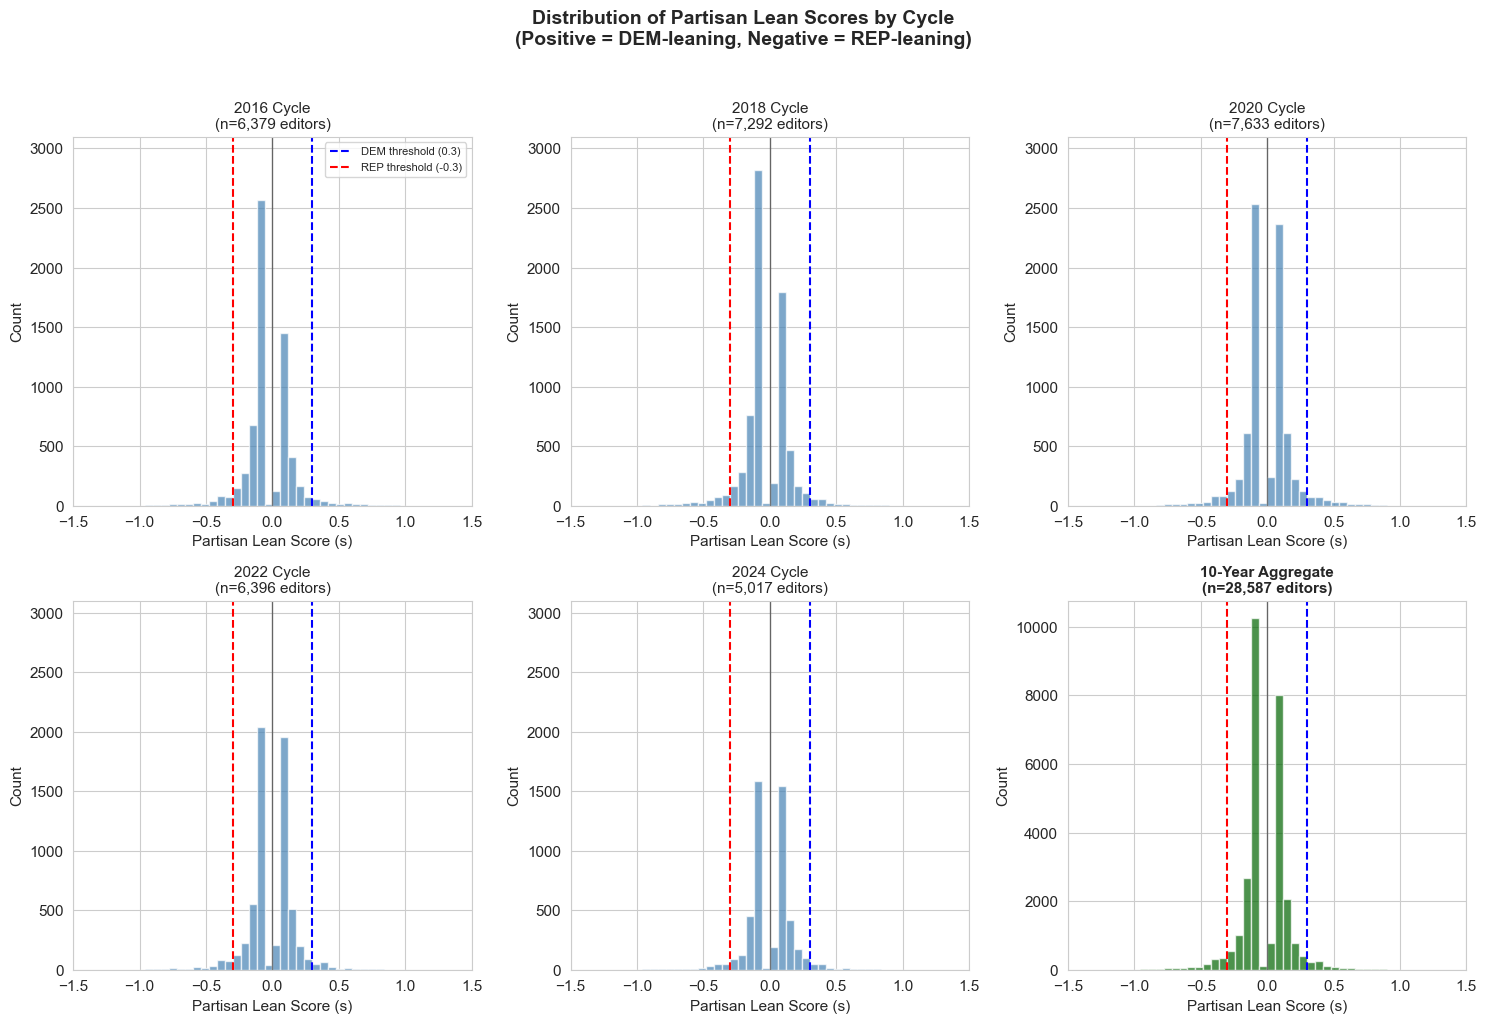


Note: The 5 cycle graphs use the same y-axis scale for easy comparison.
The 10-year aggregate (bottom right) uses its own scale due to different sample size.


In [12]:
# =============================================================================
# VISUALIZATION: DISTRIBUTION OF PARTISAN LEAN SCORES
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Compute histograms to find max y-value across all 5 cycles
max_count_cycles = 0
for year in [2016, 2018, 2020, 2022, 2024]:
    scores_df = all_cycle_scores[year]
    valid = scores_df[scores_df['score'].notna()]['score']
    counts, _ = np.histogram(valid, bins=50, range=(-1.5, 1.5))
    max_count_cycles = max(max_count_cycles, counts.max())

# Add 10% padding
y_max_cycles = max_count_cycles * 1.1

print(f"Using consistent y-axis scale for 5 cycle graphs: [0, {y_max_cycles:.0f}]")

# Plot with consistent y-axis
for i, year in enumerate([2016, 2018, 2020, 2022, 2024]):
    ax = axes[i]
    scores_df = all_cycle_scores[year]
    valid = scores_df[scores_df['score'].notna()]['score']
    
    ax.hist(valid, bins=50, range=(-1.5, 1.5), color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(DEM_THRESHOLD, color='blue', linestyle='--', linewidth=1.5, label=f'DEM threshold ({DEM_THRESHOLD})')
    ax.axvline(REP_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'REP threshold ({REP_THRESHOLD})')
    ax.set_title(f'{year} Cycle\n(n={len(valid):,} editors)', fontsize=11)
    ax.set_xlabel('Partisan Lean Score (s)')
    ax.set_ylabel('Count')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(0, y_max_cycles)  # Consistent y-axis across all 5 cycles
    if i == 0:
        ax.legend(fontsize=8)

# Plot 10-year aggregate distribution (separate scale - different sample size)
ax = axes[5]
valid_10yr_scores = scores_10yr[scores_10yr['score_10yr'].notna()]['score_10yr']
ax.hist(valid_10yr_scores, bins=50, range=(-1.5, 1.5), color='darkgreen', edgecolor='white', alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.axvline(DEM_THRESHOLD, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(REP_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f'10-Year Aggregate\n(n={len(valid_10yr_scores):,} editors)', fontsize=11, fontweight='bold')
ax.set_xlabel('Partisan Lean Score (s)')
ax.set_ylabel('Count')
ax.set_xlim(-1.5, 1.5)
# Note: 10-year aggregate uses its own scale (different sample size)

plt.suptitle('Distribution of Partisan Lean Scores by Cycle\n(Positive = DEM-leaning, Negative = REP-leaning)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: The 5 cycle graphs use the same y-axis scale for easy comparison.")
print("The 10-year aggregate (bottom right) uses its own scale due to different sample size.")


### 6.4 Stability analysis for editor partisan leaning

The 10-year score $s_e$ serves as a "baseline" or "true" partisan lean. I compare each cycle's score $s_{e,y}$ to this baseline to assess stability.

* High correlation = editors are consistent in their partisan lean over time
* Points far from diagonal = editors whose cycle behavior differs from overall pattern

In [43]:
print("="*80)
print("STABILITY ANALYSIS: Comparing Cycle Scores to 10-Year Aggregate")
print("="*80)

# Merge cycle scores with 10-year scores
stability_data = []

for year in [2016, 2018, 2020, 2022, 2024]:
    cycle_df = all_cycle_scores[year][['user', 'score', 'total']].copy()
    cycle_df.columns = ['user', f'score_{year}', f'total_{year}']
    
    merged = cycle_df.merge(
        scores_10yr[['user', 'score_10yr', 'total_all']], 
        on='user', 
        how='inner'
    )
    merged['year'] = year
    stability_data.append(merged)

df_stability = pd.concat(stability_data, ignore_index=True)

# For visualization, we need editors who appear in multiple cycles
# and have valid scores in both cycle and 10-year aggregate
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

correlations = {}

for i, year in enumerate([2016, 2018, 2020, 2022, 2024]):
    ax = axes[i]
    
    # Get data for this cycle
    cycle_df = all_cycle_scores[year].copy()
    merged = cycle_df.merge(scores_10yr[['user', 'score_10yr']], on='user', how='inner')
    
    # Filter to valid scores only
    valid = merged[(merged['score'].notna()) & (merged['score_10yr'].notna())]
    
    if len(valid) > 10:
        # Scatter plot
        ax.scatter(valid['score_10yr'], valid['score'], alpha=0.3, s=10, c='steelblue')
        
        # Add diagonal line (perfect stability)
        ax.plot([-1.5, 1.5], [-1.5, 1.5], 'k--', alpha=0.5, label='Perfect stability')
        
        # Compute correlation
        corr = valid['score'].corr(valid['score_10yr'])
        correlations[year] = corr
        
        ax.set_title(f'{year}\nr = {corr:.3f}', fontsize=11)
    else:
        ax.set_title(f'{year}\n(insufficient data)', fontsize=11)
    
    ax.set_xlabel('10-Year Score ($s_e$)')
    ax.set_ylabel(f'Cycle Score ($s_{{e,{year}}}$)')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Cycle Score vs 10-Year Score: Assessing Editor Stability\n(Points on diagonal = consistent behavior)', 
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nCorrelation between cycle scores and 10-year scores:")
for year, corr in correlations.items():
    stability_level = "High" if corr > 0.7 else "Moderate" if corr > 0.4 else "Low"
    print(f"  {year}: r = {corr:.3f} ({stability_level} stability)")

print("\nInterpretation:")
print("  - Points above diagonal: Editor more DEM-leaning in that cycle than overall")
print("  - Points below diagonal: Editor more REP-leaning in that cycle than overall")
print("\n  - Strong correlation suggests that editors maintain consistent partisan lean across cycles")



STABILITY ANALYSIS: Comparing Cycle Scores to 10-Year Aggregate


NameError: name 'all_cycle_scores' is not defined